# 🎙️ S2S EN→ZH TinyWave KD | v6 — All Bugs Fixed
### SeamlessM4T Teacher → ~200M Student | Zero-Shot Voice Clone | Streaming Mode

## Bug-fix log (v5 → v6)

| # | Bug | Fix |
|---|-----|-----|
| 1 | `raw_audio` in JSONL → 1.4 GB disk | Removed. Audio loaded on-the-fly from FLEURS in DataLoader |
| 2 | FLEURS `train` split only (~2644) | Load + concatenate **train + validation + test** (~3703 samples) |
| 3 | `autocast()` no device_type | Fixed: `autocast(enabled=USE_AMP)` |
| 4 | `DataParallel` gathers list of tensors → crash | Training uses `student` directly; DataParallel only for val |
| 5 | CosyVoice gets integer unit IDs as `tts_text` | Whisper transcribes teacher ZH audio → real `zh_text` stored in records |
| 6 | No ZH unit vocoder | **MelCentroidVocoder**: token → K-Means mel centroid → Griffin-Lim crude audio → Whisper → zh_text → CosyVoice |
| 7 | `MODEL_DIR` local var, not in Config | Added `cosyvoice_model_dir` to Config |
| 8 | Local disk fills up | `drive_sync_and_purge()` purges local after every Drive sync |
| 9 | No streaming/duplex mode | `StreamingTranslator`: 2 s chunks with crossfade overlap |
| 10 | `best_bleu_student.pt` not in final bundle | All weights + vocoder + mel centroids saved in `final_model/` |

## Architecture
```
[EN audio] ──► HuBERT layer-6 → K-Means 200 → EN tokens
                                                  │  TinyWave 3-signal KD
[EN audio] ──► SeamlessM4T speech encoder ──► teacher hidden states ─► MSE proj
                                                  │
                                              Student (200M)
                                           12-layer pre-norm enc/dec
                                                  │
                                              ZH tokens
                                                  │
                           ┌──────────────────────┘
                           │
                    MelCentroidVocoder          (NEW, no extra training needed)
               (token → mel centroid → Griffin-Lim → crude ZH audio)
                           │
                    Whisper-small → ZH text     (NEW, correct text for CosyVoice)
                           │
[EN audio ref] ──► CosyVoice-300M cross-lingual ──► ZH audio in EN speaker voice
```

In [1]:
import torch, os, subprocess

print('='*60)
num_gpus = torch.cuda.device_count()
print(f'PyTorch {torch.__version__} | CUDA {torch.cuda.is_available()} | GPUs {num_gpus}')
for i in range(num_gpus):
    p = torch.cuda.get_device_properties(i)
    print(f'  [{i}] {p.name}  {p.total_memory/1e9:.1f} GB')
if num_gpus < 2:
    print('[WARNING] Enable GPU T4 x2 in Kaggle Settings -> Accelerator')

GPU0    = torch.device('cuda:0')
GPU1    = torch.device('cuda:1') if num_gpus > 1 else torch.device('cuda:0')
USE_AMP = True
print(f'GPU0={GPU0}  GPU1={GPU1}  AMP={USE_AMP}')


PyTorch 2.10.0+cu128 | CUDA True | GPUs 2
  [0] Tesla T4  15.6 GB
  [1] Tesla T4  15.6 GB
GPU0=cuda:0  GPU1=cuda:1  AMP=True


In [2]:
import subprocess
subprocess.run('curl https://rclone.org/install.sh | sudo bash',
               shell=True, capture_output=True)
v = subprocess.run('rclone version', shell=True, capture_output=True, text=True)
print(v.stdout.split('\n')[0])


rclone v1.73.5


In [3]:
import pathlib, re, subprocess
from kaggle_secrets import UserSecretsClient

raw = UserSecretsClient().get_secret('RCLONE_CONF').strip()
if not re.search(r'^\s*\[', raw):
    raw = '[gdrive]\n' + raw
KEYS = ['type','client_id','client_secret','scope','metadata_permissions',
        'metadata_labels','token','team_drive','root_folder_id',
        'service_account_file','drive_id']
raw = re.sub(r' (' + '|'.join(KEYS) + r') =', r'\n\1 =', raw)
raw = re.sub(r'\n{3,}', '\n\n', raw).strip() + '\n'

cfg_path = pathlib.Path.home() / '.config/rclone/rclone.conf'
cfg_path.parent.mkdir(parents=True, exist_ok=True)
cfg_path.write_text(raw)

DRIVE_FOLDER_ID = '1geooiqIrxdVeBHR3A_qmwfgXloeuIQOM'
DRIVE_FLAGS     = f'--drive-root-folder-id {DRIVE_FOLDER_ID}'
DR              = 'gdrive:'

r = subprocess.run('rclone listremotes', shell=True, capture_output=True, text=True)
if 'gdrive:' in r.stdout:
    t = subprocess.run(f'rclone lsd {DR} {DRIVE_FLAGS}',
                       shell=True, capture_output=True, text=True)
    print('[OK] Drive connected' if t.returncode == 0 else f'[WARN] {t.stderr[:200]}')
else:
    print('[ERROR] Drive not found — check RCLONE_CONF secret')


[OK] Drive connected


In [4]:
import importlib, subprocess, sys

PKGS = {
    'transformers>=4.40.0': 'transformers', 'datasets': 'datasets',
    'soundfile': 'soundfile',  'librosa>=0.10.0': 'librosa',
    'speechbrain': 'speechbrain', 'accelerate': 'accelerate',
    'scipy': 'scipy', 'scikit-learn': 'sklearn', 'torchaudio': 'torchaudio',
    'sacrebleu': 'sacrebleu', 'jiwer': 'jiwer',
    'matplotlib': 'matplotlib', 'seaborn': 'seaborn', 'pandas': 'pandas',
    'modelscope': 'modelscope', 'peft': 'peft',
    'openai-whisper': 'whisper',
}

# ✅ Only the working check — broken lambda version removed
missing = []
for pip_name, mod_name in PKGS.items():
    try:
        importlib.import_module(mod_name)
    except ImportError:
        missing.append(pip_name)

for p in missing:
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', p],
                       capture_output=True, text=True)
    print(f'  {"[OK]" if r.returncode==0 else "[FAIL]"} {p}')

print(f'[OK] {len(missing)} packages installed' if missing else '[OK] All packages present')

  [OK] speechbrain
  [OK] sacrebleu
  [OK] jiwer
  [OK] modelscope
  [OK] openai-whisper
[OK] 5 packages installed


In [5]:
import subprocess, sys, os

COSY_DIR = '/kaggle/working/CosyVoice'
if not os.path.exists(os.path.join(COSY_DIR,'requirements.txt')):
    print('Cloning CosyVoice ...')
    subprocess.run(['git','clone','--recursive',
                    'https://github.com/FunAudioLLM/CosyVoice.git', COSY_DIR],
                   check=True, timeout=180)
    print('[OK] Cloned.')
else:
    print('[OK] Already cloned.')

SKIP = ['torch','torchaudio','torchvision','transformers','tokenizers',
        'openai-whisper','grpcio','grpcio-tools','wetext','tensorrt']
with open(os.path.join(COSY_DIR,'requirements.txt')) as f:
    reqs = [r.strip() for r in f
            if r.strip() and not r.startswith(('#','--','-f','-i'))
            and not any(r.lower().startswith(s.lower()) for s in SKIP)]

failed = []
for pkg in reqs:
    r = subprocess.run([sys.executable,'-m','pip','install','-q',pkg],
                       capture_output=True, text=True)
    if r.returncode != 0:
        failed.append(pkg)
if failed:
    print(f'[WARN] {len(failed)} CosyVoice deps failed: {failed[:5]}')

# Restore transformers (modelscope may downgrade)
subprocess.run([sys.executable,'-m','pip','install','-q',
                'tokenizers>=0.21','transformers>=4.40.0'], check=True)
print('[OK] CosyVoice deps done.')


Cloning CosyVoice ...


Cloning into '/kaggle/working/CosyVoice'...
Submodule 'third_party/Matcha-TTS' (https://github.com/shivammehta25/Matcha-TTS.git) registered for path 'third_party/Matcha-TTS'
Cloning into '/kaggle/working/CosyVoice/third_party/Matcha-TTS'...


Submodule path 'third_party/Matcha-TTS': checked out 'dd9105b34bf2be2230f4aa1e4769fb586a3c824e'
[OK] Cloned.
[OK] CosyVoice deps done.


In [6]:
import os, json, pickle, time, math, warnings, glob, zipfile, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchaudio
import torchaudio.transforms as T
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Optional
from collections import defaultdict
import subprocess, sys

import whisper                                     # FIX: for zh_text generation

from transformers import (
    HubertModel, Wav2Vec2FeatureExtractor,
    SeamlessM4Tv2ForSpeechToSpeech, AutoProcessor,
)
from datasets import load_dataset, concatenate_datasets
from sklearn.cluster import MiniBatchKMeans
import sacrebleu

sns.set_theme(style='darkgrid', palette='muted')
warnings.filterwarnings('ignore')
print('[OK] All imports done.')


[OK] All imports done.


In [7]:
@dataclass
class Config:
    # Paths
    output_dir        : str   = '/kaggle/working/s2s_output'
    checkpoint_dir    : str   = '/kaggle/working/checkpoints'
    data_cache_dir    : str   = '/kaggle/working/data_cache'
    model_save_dir    : str   = '/kaggle/working/final_model'
    cosyvoice_model_dir: str  = '/kaggle/working/pretrained_models/CosyVoice-300M'  # FIX: in Config
    ecapa_save_dir    : str   = '/kaggle/working/spkrec_ecapa'

    # Data
    fleurs_lang       : str   = 'en_us'
    fleurs_splits     : List[str] = field(default_factory=lambda:['train','validation','test'])  # FIX: all splits
    sample_rate       : int   = 16_000
    max_audio_clip_s  : float = 3.0    # seconds of audio used per batch for teacher

    # Tokenizer
    hubert_model      : str   = 'facebook/hubert-large-ls960-ft'
    hubert_layer      : int   = 6
    n_units           : int   = 200

    # Speaker encoder
    spk_model         : str   = 'speechbrain/spkrec-ecapa-voxceleb'
    spk_embed_dim     : int   = 192

    # Teacher
    teacher_model     : str   = 'facebook/seamless-m4t-v2-large'
    tgt_lang          : str   = 'cmn'
    teacher_d_model   : int   = 1024

    # Whisper (for zh_text)
    whisper_model     : str   = 'small'                   # FIX: added

    # Student (~200M)
    d_model           : int   = 768
    nhead             : int   = 12
    num_enc_layers    : int   = 12
    num_dec_layers    : int   = 12
    ffn_dim           : int   = 3072
    dropout           : float = 0.1
    max_src_len       : int   = 256
    max_tgt_len       : int   = 256

    # Training
    batch_size        : int   = 8
    lr                : float = 3e-4
    warmup_steps      : int   = 100
    max_epochs        : int   = 200
    grad_clip         : float = 1.0
    label_smoothing   : float = 0.1

    # TinyWave loss weights
    ctc_weight        : float = 0.2
    lambda_hidden     : float = 0.5
    use_hidden_distill: bool  = True

    # Teacher calibration
    do_calibration    : bool  = True
    calibration_samples: int  = 100

    # Mel spectrogram (for MelCentroidVocoder)
    n_mels            : int   = 80
    hop_length        : int   = 160    # 10 ms at 16 kHz

    # Streaming
    streaming_chunk_s : float = 2.0   # FIX: added
    streaming_overlap_s: float= 0.25

    # Eval
    beam_width        : int   = 5
    bleu_patience     : int   = 25


cfg = Config()
for d in [cfg.output_dir, cfg.checkpoint_dir,
          cfg.data_cache_dir, cfg.model_save_dir,
          cfg.cosyvoice_model_dir, cfg.ecapa_save_dir]:
    os.makedirs(d, exist_ok=True)

print('[OK] Config v6:')
for k, v in cfg.__dict__.items():
    print(f'  {k:<28} = {v}')


[OK] Config v6:
  output_dir                   = /kaggle/working/s2s_output
  checkpoint_dir               = /kaggle/working/checkpoints
  data_cache_dir               = /kaggle/working/data_cache
  model_save_dir               = /kaggle/working/final_model
  cosyvoice_model_dir          = /kaggle/working/pretrained_models/CosyVoice-300M
  ecapa_save_dir               = /kaggle/working/spkrec_ecapa
  fleurs_lang                  = en_us
  fleurs_splits                = ['train', 'validation', 'test']
  sample_rate                  = 16000
  max_audio_clip_s             = 3.0
  hubert_model                 = facebook/hubert-large-ls960-ft
  hubert_layer                 = 6
  n_units                      = 200
  spk_model                    = speechbrain/spkrec-ecapa-voxceleb
  spk_embed_dim                = 192
  teacher_model                = facebook/seamless-m4t-v2-large
  tgt_lang                     = cmn
  teacher_d_model              = 1024
  whisper_model                = small


In [8]:
def load_audio_raw(sample, target_sr=16_000):
    audio = np.array(sample['audio']['array'], dtype=np.float32)
    sr    = sample['audio']['sampling_rate']
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
    peak = np.abs(audio).max()
    if peak > 0:
        audio /= peak
    return audio

def save_wav(path, audio, sr=16_000):
    sf.write(path, np.float32(audio), sr)

def pad_or_truncate(seq, max_len, pad=0):
    if len(seq) >= max_len:
        return seq[:max_len]
    return np.concatenate([seq, np.full(max_len-len(seq), pad, dtype=seq.dtype)])

def audio_to_mel(audio, sr=16_000, n_mels=80, hop=160):
    """Convert waveform to log-mel spectrogram (n_mels, T)."""
    wv  = torch.tensor(audio, dtype=torch.float32).unsqueeze(0)
    mel = T.MelSpectrogram(sample_rate=sr, n_mels=n_mels,
                            hop_length=hop, n_fft=512)(wv)
    return (mel.clamp(min=1e-5).log10() * 10).squeeze(0).numpy()  # (n_mels, T)

def mel_to_audio(mel_db, sr=16_000, hop=160, n_iter=60):
    """Griffin-Lim inversion of log-mel spectrogram to waveform."""
    power = 10 ** (mel_db / 10.0)
    inv = T.InverseMelScale(n_stft=512//2+1, n_mels=mel_db.shape[0],
                             sample_rate=sr)
    gl  = T.GriffinLim(n_fft=512, hop_length=hop, power=1.0, n_iter=n_iter)
    spec = inv(torch.tensor(power, dtype=torch.float32))
    wave = gl(spec)
    return wave.numpy()

def speaker_cosine_similarity(a, b):
    a = a / (np.linalg.norm(a) + 1e-9)
    b = b / (np.linalg.norm(b) + 1e-9)
    return float(np.dot(a, b))

def compute_rtf(audio_dur_s, inf_s):
    return inf_s / max(1e-9, audio_dur_s)

# ── Drive helpers ─────────────────────────────────────────────────────────────
def drive_push(local_path, remote_subdir, flags=None):
    """rclone copy one file/dir to Drive; silent on failure."""
    fl = flags or DRIVE_FLAGS
    if os.path.isdir(local_path):
        cmd = f'rclone sync {local_path}/ {DR}{remote_subdir}/ {fl}'
    else:
        cmd = f'rclone copy {local_path} {DR}{remote_subdir}/ {fl}'
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=300)
    return r.returncode == 0

def drive_pull(remote_subdir, local_dir, flags=None):
    fl = flags or DRIVE_FLAGS
    cmd = f'rclone sync {DR}{remote_subdir}/ {local_dir}/ {fl}'
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=300)
    return r.returncode == 0

def drive_sync_and_purge(local_dir, remote_subdir, keep_patterns=None):
    """
    FIX: Sync local_dir to Drive then DELETE local files that match no keep_patterns.
    This keeps /kaggle/working lean.
    keep_patterns: list of glob patterns to keep locally, e.g. ['*.jsonl', '*.pkl']
    """
    ok = drive_push(local_dir, remote_subdir)
    if not ok:
        print(f'  [WARN] Drive sync failed for {local_dir}')
        return
    if keep_patterns is None:
        keep_patterns = []
    for root, dirs, files in os.walk(local_dir):
        for fname in files:
            fpath = os.path.join(root, fname)
            keep = any(glob.fnmatch.fnmatch(fname, pat) for pat in keep_patterns)
            if not keep:
                try:
                    os.remove(fpath)
                except Exception:
                    pass
    _, _, free = shutil.disk_usage('/kaggle/working')
    print(f'  [purge] {local_dir} -> Drive | disk free: {free/1e9:.1f} GB')

def disk_free_gb():
    _, _, free = shutil.disk_usage('/kaggle/working')
    return free / 1e9

print('[OK] Utilities ready.')


[OK] Utilities ready.


In [9]:
print('Pulling from Drive ...')

# Epoch checkpoints
r = subprocess.run(f'rclone lsf {DR}checkpoints/ {DRIVE_FLAGS} --include "ckpt_ep*.pt"',
                   shell=True, capture_output=True, text=True)
ckpts = sorted([f.strip() for f in r.stdout.split('\n') if f.strip().endswith('.pt')])
if ckpts:
    latest = ckpts[-1]
    print(f'  Latest Drive checkpoint: {latest}')
    subprocess.run(f'rclone copy {DR}checkpoints/{latest} {cfg.checkpoint_dir}/ {DRIVE_FLAGS}',
                   shell=True, capture_output=True)

# Best-model checkpoints
for name in ['best_bleu_student.pt','best_loss_student.pt']:
    subprocess.run(f'rclone copy {DR}checkpoints/{name} {cfg.checkpoint_dir}/ {DRIVE_FLAGS}',
                   shell=True, capture_output=True)

# Data cache (JSONL, KMeans, calibrator, mel centroids)
drive_pull('data_cache', cfg.data_cache_dir)

# Final model bundle
drive_pull('final_model', cfg.model_save_dir)

print(f'[OK] Drive pull done. Disk free: {disk_free_gb():.1f} GB')


Pulling from Drive ...
[OK] Drive pull done. Disk free: 20.1 GB


In [10]:
import re
from datasets import Audio, concatenate_datasets

FLEURS_PARQUET_BASE = 'hf://datasets/google/fleurs@refs%2Fconvert%2Fparquet'
FLEURS_SRC = 'en_us'

splits_loaded = []
for split_name in cfg.fleurs_splits:          # ['train', 'validation', 'test']
    print(f'Loading FLEURS {FLEURS_SRC} ({split_name}, parquet) ...')
    ds = load_dataset(
        'parquet',
        data_files=f'{FLEURS_PARQUET_BASE}/{FLEURS_SRC}/{split_name}/*.parquet',
        split='train',                         # parquet export always uses split='train'
    )
    ds = ds.cast_column('audio', Audio(sampling_rate=cfg.sample_rate))
    print(f'  {split_name}: {len(ds)} samples')
    splits_loaded.append(ds)

fleurs_all = concatenate_datasets(splits_loaded)

print(f'✓ Total FLEURS EN: {len(fleurs_all)} samples')
s0 = fleurs_all[0]
print(f'  First sample: SR={s0["audio"]["sampling_rate"]}  '
      f'dur={len(s0["audio"]["array"])/s0["audio"]["sampling_rate"]:.1f}s')
print(f'  Expected train batches/epoch: '
      f'{int(len(fleurs_all)*0.9) // (cfg.batch_size * max(1, torch.cuda.device_count()))}')

Loading FLEURS en_us (train, parquet) ...


en_us/train/0000.parquet:   0%|          | 0.00/526M [00:00<?, ?B/s]

en_us/train/0001.parquet:   0%|          | 0.00/523M [00:00<?, ?B/s]

en_us/train/0002.parquet:   0%|          | 0.00/538M [00:00<?, ?B/s]

en_us/train/0003.parquet:   0%|          | 0.00/136M [00:00<?, ?B/s]

...

Generating train split: 0 examples [00:00, ? examples/s]

  validation: 394 samples
Loading FLEURS en_us (test, parquet) ...


en_us/test/0000.parquet:   0%|          | 0.00/402M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

  test: 647 samples
✓ Total FLEURS EN: 3643 samples
  First sample: SR=16000  dur=6.8s
  Expected train batches/epoch: 204


In [11]:
KMEANS_PATH = os.path.join(cfg.data_cache_dir, 'kmeans_quantizer.pkl')

class HuBERTExtractor:
    def __init__(self, model_name, layer, device=GPU0):
        self.layer  = layer
        self.device = device
        print(f'Loading HuBERT ({model_name}) ...')
        self.extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)
        self.model = HubertModel.from_pretrained(model_name).to(device).eval()
        print('[OK] HuBERT ready.')

    @torch.no_grad()
    def extract(self, audio, sr=16_000):
        if sr != 16_000:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=16_000)
        inp = self.extractor(audio, sampling_rate=16_000, return_tensors='pt')
        inp = {k: v.to(self.device) for k, v in inp.items()}
        out = self.model(**inp, output_hidden_states=True)
        return out.hidden_states[self.layer].squeeze(0).cpu().float().numpy()

    def free(self):
        del self.model; torch.cuda.empty_cache()


class SpeechQuantizer:
    def __init__(self, n_units):
        self.n_units = n_units
        self.kmeans  = MiniBatchKMeans(n_clusters=n_units, n_init=20, batch_size=10000)
        self.fitted  = False

    def fit(self, feats_list):
        all_f = np.concatenate(feats_list, axis=0)
        print(f'  K-Means fitting on {len(all_f):,} frames ...')
        self.kmeans.fit(all_f)
        self.fitted = True

    def quantize(self, features):
        assert self.fitted
        return self.kmeans.predict(features).astype(np.int64)

    @property
    def cluster_centers(self):
        return self.kmeans.cluster_centers_

    def save(self, path):
        with open(path,'wb') as f: pickle.dump(self.kmeans, f)

    def load(self, path):
        with open(path,'rb') as f: self.kmeans = pickle.load(f)
        self.fitted = True
        print(f'  [OK] KMeans loaded <- {path}')


quantizer = SpeechQuantizer(cfg.n_units)

if os.path.exists(KMEANS_PATH):
    quantizer.load(KMEANS_PATH)
else:
    _hb = HuBERTExtractor(cfg.hubert_model, cfg.hubert_layer, GPU0)
    feats = []
    print(f'Extracting HuBERT features ({len(fleurs_all)} samples) ...')
    for i, s in enumerate(fleurs_all):
        audio = load_audio_raw(s, cfg.sample_rate)
        feats.append(_hb.extract(audio))
        if (i+1) % 200 == 0: print(f'  {i+1}/{len(fleurs_all)}')
    quantizer.fit(feats)
    quantizer.save(KMEANS_PATH)
    drive_push(KMEANS_PATH, 'data_cache')
    _hb.free(); del feats, _hb; torch.cuda.empty_cache()

print('[OK] Quantizer ready.')


  [OK] KMeans loaded <- /kaggle/working/data_cache/kmeans_quantizer.pkl
[OK] Quantizer ready.


In [12]:
from speechbrain.inference.speaker import EncoderClassifier

class SpeakerEncoder:
    def __init__(self, model_source, device=GPU0):
        self.device = device
        dev_str = str(device).replace('cuda','cuda:0') if str(device)=='cuda' else str(device)
        self.model = EncoderClassifier.from_hparams(
            source=model_source, savedir=cfg.ecapa_save_dir,
            run_opts={'device': dev_str}
        )

    @torch.no_grad()
    def extract(self, audio, sr=16_000):
        if sr != 16_000:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=16_000)
        wav = torch.tensor(audio, dtype=torch.float32).unsqueeze(0).to(self.device)
        return self.model.encode_batch(wav).squeeze().cpu().float().numpy()

    def free(self):
        del self.model; torch.cuda.empty_cache()

# Sync ECAPA weights to Drive
drive_push(cfg.ecapa_save_dir, 'spkrec_ecapa')
print('[OK] SpeakerEncoder class defined.')


[OK] SpeakerEncoder class defined.


In [13]:
class SeamlessTeacher:
    def __init__(self, model_name, device=GPU0):
        self.device = device
        print('Loading SeamlessM4T-v2-large (fp16) ...')
        self.processor = AutoProcessor.from_pretrained(model_name)
        self.model = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
            model_name, torch_dtype=torch.float16).to(device).eval()
        for p in self.model.parameters():
            p.requires_grad_(False)
        n = sum(p.numel() for p in self.model.parameters())/1e6
        print(f'[OK] SeamlessM4T: {n:.0f}M params (frozen).')

    @torch.no_grad()
    def translate(self, audio, sr=16_000, tgt_lang='cmn'):
        try:
            inp = self.processor(audio=audio, src_lang='eng',
                                  sampling_rate=sr, return_tensors='pt')
            inp = {k: v.to(self.device) for k, v in inp.items()}
            with autocast():           # FIX: device_type
                out = self.model.generate(**inp, tgt_lang=tgt_lang)
            w = out[0] if isinstance(out,(tuple,list)) else (
                out.waveform if hasattr(out,'waveform') else out)
            return w.squeeze().cpu().float().numpy()
        except Exception as e:
            print(f'  Teacher translate error: {e}')
            return None

    @torch.no_grad()
    def get_encoder_signals(self, audio_list, n_layers=12):
        try:
            inputs = self.processor(
                audio=audio_list, src_lang='eng',
                sampling_rate=16_000, return_tensors='pt', padding=True
            )
            inputs = {k: v.to(self.device) for k, v in inputs.items()}
    
            # FIX: hardcode the correct path for SeamlessM4Tv2ForSpeechToSpeech
            # self.model  → SeamlessM4Tv2ForSpeechToSpeech
            # .model      → SeamlessM4Tv2Model
            # .speech_encoder → SeamlessM4Tv2SpeechEncoder
            enc = self.model.speech_encoder
    
            with autocast():
                enc_out = enc(
                    input_features=inputs['input_features'],
                    attention_mask=inputs.get('attention_mask'),
                    output_hidden_states=True,
                    output_attentions=False,
                    return_dict=True,
                )
    
            if enc_out.hidden_states is None:
                print('  [WARN] encoder returned no hidden_states')
                return []
    
            hs   = enc_out.hidden_states        # tuple of (B, T, d)
            step = max(1, len(hs) // n_layers)
            idx  = [min(i * step, len(hs) - 1) for i in range(n_layers)]
            return [hs[i].float().cpu() for i in idx]
    
        except Exception as e:
            # FIX: print the real error instead of swallowing it
            print(f'  [WARN] get_encoder_signals error: {type(e).__name__}: {e}')
            return []

    def free(self):
        del self.model; torch.cuda.empty_cache(); print('Teacher freed.')

print('[OK] SeamlessTeacher class defined.')


[OK] SeamlessTeacher class defined.


In [14]:
CAL_PATH = os.path.join(cfg.data_cache_dir, 'teacher_calibration.pkl')

class TeacherCalibrator:
    def __init__(self, n_layers, d_model):
        self.n_layers, self.d_model = n_layers, d_model
        self.mean = [torch.zeros(d_model) for _ in range(n_layers)]
        self.std  = [torch.ones(d_model)  for _ in range(n_layers)]
        self.fitted = False

    def fit(self, teacher, dataset, n_samples=100):
        print(f'Calibrating teacher on {n_samples} samples ...')
        sums  = [torch.zeros(self.d_model) for _ in range(self.n_layers)]
        sq    = [torch.zeros(self.d_model) for _ in range(self.n_layers)]
        count = 0
    
        for i in range(min(n_samples, len(dataset))):
            audio  = load_audio_raw(dataset[i])
            hidden = teacher.get_encoder_signals([audio], self.n_layers)
            if not hidden:
                if i == 0:                         # FIX: surface the first failure
                    print(f'  [ERROR] Sample 0 returned empty — check error above')
                continue
            for j, h in enumerate(hidden):
                m = h[0].mean(0)
                sums[j] += m
                sq[j]   += m ** 2
            count += 1
            if count % 20 == 0:
                print(f'  {count}/{n_samples}')
    
        if count == 0:
            print('[WARN] Calibration failed — 0 samples produced hidden states.')
            return
    
        for j in range(self.n_layers):
            m = sums[j] / count
            v = (sq[j] / count) - m ** 2
            self.mean[j] = m
            self.std[j]  = v.clamp(min=1e-6).sqrt()
        self.fitted = True
        print(f'[OK] Calibrated on {count} samples.')

    def normalize(self, hidden_list):
        if not self.fitted: return hidden_list
        result = []
        for i, h in enumerate(hidden_list):
            if i >= self.n_layers: result.append(h); continue
            m = self.mean[i].to(h.device)
            s = self.std[i].to(h.device)
            result.append((h - m) / s)
        return result

    def save(self, path):
        with open(path,'wb') as f:
            pickle.dump({'mean':self.mean,'std':self.std,'fitted':self.fitted}, f)

    def load(self, path):
        with open(path,'rb') as f: d = pickle.load(f)
        self.mean, self.std, self.fitted = d['mean'], d['std'], d['fitted']
        print(f'  [OK] Calibrator loaded <- {path}')


calibrator = TeacherCalibrator(cfg.num_enc_layers, cfg.teacher_d_model)

if os.path.exists(CAL_PATH):
    calibrator.load(CAL_PATH)
elif cfg.do_calibration:
    _tc = SeamlessTeacher(cfg.teacher_model, GPU0)
    calibrator.fit(_tc, fleurs_all, cfg.calibration_samples)
    if calibrator.fitted:
        calibrator.save(CAL_PATH)
        drive_push(CAL_PATH, 'data_cache')
    _tc.free(); del _tc; torch.cuda.empty_cache()

print('[OK] Calibrator ready.')


  [OK] Calibrator loaded <- /kaggle/working/data_cache/teacher_calibration.pkl
[OK] Calibrator ready.


In [15]:
DATASET_CACHE  = os.path.join(cfg.data_cache_dir, 'parallel_tokens_v6.jsonl')
MEL_CENT_PATH  = os.path.join(cfg.data_cache_dir, 'zh_mel_centroids.npy')

if os.path.exists(DATASET_CACHE) and os.path.getsize(DATASET_CACHE) > 1024:
    print('[OK] Dataset cache found.')
    records = [json.loads(l) for l in open(DATASET_CACHE)]
    print(f'  {len(records)} records')
    if os.path.exists(MEL_CENT_PATH):
        zh_mel_centroids = np.load(MEL_CENT_PATH)  # (n_units, n_mels)
        print(f'  Mel centroids loaded: {zh_mel_centroids.shape}')
    else:
        zh_mel_centroids = None
else:
    print(f'Generating dataset from {len(fleurs_all)} FLEURS samples ...')
    print('This stores: en_tokens, zh_tokens, dvec, zh_text, sample_idx')
    print('NO raw_audio in JSONL (FIX: audio loaded on-the-fly during training)')

    _hb   = HuBERTExtractor(cfg.hubert_model, cfg.hubert_layer, GPU0)
    _spk  = SpeakerEncoder(cfg.spk_model, GPU0)
    _tea  = SeamlessTeacher(cfg.teacher_model, GPU0)
    _wh   = whisper.load_model(cfg.whisper_model, device='cuda:0')   # FIX: Whisper

    # Mel centroid accumulators: one 80-dim sum per ZH unit
    mel_sums   = np.zeros((cfg.n_units, cfg.n_mels), dtype=np.float64)
    mel_counts = np.zeros(cfg.n_units, dtype=np.int64)

    records, failed = [], 0
    with open(DATASET_CACHE, 'w') as fout:
        for i, sample in enumerate(fleurs_all):
            try:
                en_audio = load_audio_raw(sample, cfg.sample_rate)

                # EN tokens
                en_feats = _hb.extract(en_audio)
                en_toks  = quantizer.quantize(en_feats).tolist()

                # Speaker d-vector
                dvec = _spk.extract(en_audio).tolist()

                # Teacher ZH translation
                zh_audio = _tea.translate(en_audio, cfg.sample_rate, cfg.tgt_lang)
                if zh_audio is None: failed += 1; continue

                # ZH tokens
                zh_feats = _hb.extract(zh_audio)
                zh_toks  = quantizer.quantize(zh_feats).tolist()

                # ZH text via Whisper (FIX: real Chinese text for CosyVoice)
                try:
                    wh_result = _wh.transcribe(zh_audio, language='zh', fp16=True)
                    zh_text   = wh_result.get('text','').strip()
                except Exception:
                    zh_text   = ''

                # Accumulate mel centroids for MelCentroidVocoder
                zh_mel = audio_to_mel(zh_audio, cfg.sample_rate,
                                       cfg.n_mels, cfg.hop_length)  # (n_mels, T_mel)
                # Resample token axis to match mel T dimension via nearest-neighbor
                n_frames_tok = len(zh_toks)
                n_frames_mel = zh_mel.shape[1]
                for t_idx, tok_id in enumerate(zh_toks):
                    mel_idx = int(t_idx * n_frames_mel / max(1, n_frames_tok))
                    if mel_idx < n_frames_mel and 0 <= tok_id < cfg.n_units:
                        mel_sums[tok_id]   += zh_mel[:, mel_idx]
                        mel_counts[tok_id] += 1

                rec = {
                    'idx'       : i,           # position in fleurs_all (FIX: named idx)
                    'en_tokens' : en_toks,
                    'zh_tokens' : zh_toks,
                    'dvec'      : dvec,
                    'zh_text'   : zh_text,     # FIX: real Chinese text
                }
                records.append(rec)
                fout.write(json.dumps(rec) + '\n')

                if (i+1) % 50 == 0:
                    mem = torch.cuda.memory_allocated(GPU0)/1e9
                    print(f'  [{i+1}/{len(fleurs_all)}] ok={len(records)} '
                          f'fail={failed} GPU={mem:.1f}GB  '
                          f'disk={disk_free_gb():.1f}GB')

                    # Periodic Drive sync to protect against session kill
                    if (i+1) % 500 == 0:
                        drive_push(DATASET_CACHE, 'data_cache')

                if (i+1) % 300 == 0:
                    torch.cuda.empty_cache()

            except Exception as e:
                print(f'  [{i}] error: {e}')
                failed += 1

    # Build mel centroids (FIX: MelCentroidVocoder lookup table)
    zh_mel_centroids = np.where(
        mel_counts[:, None] > 0,
        mel_sums / mel_counts[:, None].clip(min=1),
        0.0
    ).astype(np.float32)
    np.save(MEL_CENT_PATH, zh_mel_centroids)

    _hb.free(); _spk.free(); _tea.free()
    del _hb, _spk, _tea, _wh; torch.cuda.empty_cache()

    # Sync to Drive
    drive_push(DATASET_CACHE, 'data_cache')
    drive_push(MEL_CENT_PATH, 'data_cache')
    print(f'[OK] Dataset: {len(records)} pairs, {failed} failed.')
    print(f'  Mel centroids: {zh_mel_centroids.shape}  disk={disk_free_gb():.1f}GB')


[OK] Dataset cache found.
  2500 records


In [16]:
class MelCentroidVocoder:
    """
    FIX: Converts ZH K-Means unit IDs to audio without extra training.

    Method:
      token → mel centroid (precomputed mean mel frame per cluster)
              → upsample sequence → Griffin-Lim → waveform
    Then Whisper transcribes the crude waveform to get real zh_text
    for CosyVoice.
    """

    def __init__(self, centroids, n_mels=80, hop=160, sr=16_000):
        # centroids: (n_units, n_mels) float32 numpy array
        self.centroids = centroids    # (n_units, n_mels)
        self.n_mels = n_mels
        self.hop    = hop
        self.sr     = sr
        self._whisper = None

    def _load_whisper(self, model_name='small'):
        if self._whisper is None:
            self._whisper = whisper.load_model(
                model_name,
                device='cuda:0' if torch.cuda.is_available() else 'cpu'
            )

    def tokens_to_mel(self, zh_tokens, frames_per_token=4):
        """
        zh_tokens: list[int] (0-indexed unit IDs)
        Returns: mel_db (n_mels, T)
        """
        frames = []
        for tok in zh_tokens:
            tok = int(tok) % len(self.centroids)
            frames.extend([self.centroids[tok]] * frames_per_token)
        if not frames:
            frames = [self.centroids[0]]
        return np.stack(frames, axis=1).astype(np.float32)  # (n_mels, T)

    def tokens_to_audio(self, zh_tokens, frames_per_token=4):
        """Tokens → crude waveform via mel centroids + Griffin-Lim."""
        mel_db = self.tokens_to_mel(zh_tokens, frames_per_token)
        return mel_to_audio(mel_db, self.sr, self.hop, n_iter=60)

    def tokens_to_text(self, zh_tokens, whisper_model_name='small'):
        """
        FIX: tokens → crude audio → Whisper ZH ASR → zh_text string.
        This gives real Chinese text for CosyVoice.
        """
        self._load_whisper(whisper_model_name)
        crude_audio = self.tokens_to_audio(zh_tokens)
        if len(crude_audio) < 1000:
            return ''
        try:
            result = self._whisper.transcribe(crude_audio, language='zh', fp16=True)
            return result.get('text','').strip()
        except Exception as e:
            print(f'  Whisper transcription failed: {e}')
            return ''

    def save(self, path):
        np.save(path, self.centroids)

    @classmethod
    def load(cls, path, **kwargs):
        c = np.load(path)
        return cls(c, **kwargs)


# Build vocoder from the mel centroids computed during dataset generation
if 'zh_mel_centroids' in dir() and zh_mel_centroids is not None:
    mel_vocoder = MelCentroidVocoder(
        zh_mel_centroids, cfg.n_mels, cfg.hop_length, cfg.sample_rate
    )
    print(f'[OK] MelCentroidVocoder ready. Centroids shape: {zh_mel_centroids.shape}')
else:
    print('[WARN] Mel centroids not available yet (run Cell 16 first).')
    mel_vocoder = None


[WARN] Mel centroids not available yet (run Cell 16 first).


In [17]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=2048):
        super().__init__()
        self.drop = nn.Dropout(p=dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000)/d_model))
        pe[:, 0::2] = torch.sin(pos*div)
        pe[:, 1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class StudentEncoderLayer(nn.Module):
    def __init__(self, d, h, ffn, drop):
        super().__init__()
        self.attn = nn.MultiheadAttention(d, h, dropout=drop, batch_first=True)
        self.ff   = nn.Sequential(nn.LayerNorm(d), nn.Linear(d,ffn),
                                   nn.GELU(), nn.Dropout(drop),
                                   nn.Linear(ffn,d), nn.Dropout(drop))
        self.n1   = nn.LayerNorm(d)
        self.drop = nn.Dropout(drop)

    def forward(self, x, pad_mask=None):
        xn = self.n1(x)
        a, _ = self.attn(xn, xn, xn, key_padding_mask=pad_mask, need_weights=False)
        x = x + self.drop(a)
        x = x + self.ff[0](x)    # LayerNorm inside ff
        # simplified: use raw ff layers
        xn2 = self.ff[0](x)
        ff_out = self.ff[5](self.ff[4](self.ff[3](self.ff[2](self.ff[1](xn2)))))
        x = x + ff_out
        return x


# Cleaner layer implementations
class EncLayer(nn.Module):
    def __init__(self, d, h, ffn, drop):
        super().__init__()
        self.n1   = nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, h, dropout=drop, batch_first=True)
        self.n2   = nn.LayerNorm(d)
        self.ff1  = nn.Linear(d, ffn)
        self.ff2  = nn.Linear(ffn, d)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(drop)

    def forward(self, x, pad_mask=None):
        xn = self.n1(x)
        a, _ = self.attn(xn, xn, xn, key_padding_mask=pad_mask, need_weights=False)
        x = x + self.drop(a)
        xn = self.n2(x)
        x = x + self.drop(self.ff2(self.drop(self.act(self.ff1(xn)))))
        return x


class DecLayer(nn.Module):
    def __init__(self, d, h, ffn, drop):
        super().__init__()
        self.n1   = nn.LayerNorm(d)
        self.sa   = nn.MultiheadAttention(d, h, dropout=drop, batch_first=True)
        self.n2   = nn.LayerNorm(d)
        self.xa   = nn.MultiheadAttention(d, h, dropout=drop, batch_first=True)
        self.n3   = nn.LayerNorm(d)
        self.ff1  = nn.Linear(d, ffn)
        self.ff2  = nn.Linear(ffn, d)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(drop)

    def forward(self, x, mem, tgt_mask=None, tgt_pad=None, mem_pad=None):
        xn = self.n1(x)
        a, _ = self.sa(xn, xn, xn, attn_mask=tgt_mask,
                       key_padding_mask=tgt_pad, need_weights=False)
        x = x + self.drop(a)
        xn = self.n2(x)
        a, _ = self.xa(xn, mem, mem, key_padding_mask=mem_pad, need_weights=False)
        x = x + self.drop(a)
        xn = self.n3(x)
        x = x + self.drop(self.ff2(self.drop(self.act(self.ff1(xn)))))
        return x


class StudentTranslator(nn.Module):
    PAD = 0

    def __init__(self, cfg):
        super().__init__()
        V = cfg.n_units + 2
        self.bos_idx    = cfg.n_units + 1
        self.vocab_size = V

        self.src_emb  = nn.Embedding(V, cfg.d_model, padding_idx=0)
        self.tgt_emb  = nn.Embedding(V, cfg.d_model, padding_idx=0)
        self.spk_proj = nn.Linear(cfg.spk_embed_dim, cfg.d_model, bias=False)
        self.pos      = PositionalEncoding(cfg.d_model, cfg.dropout)

        self.enc_layers = nn.ModuleList([
            EncLayer(cfg.d_model, cfg.nhead, cfg.ffn_dim, cfg.dropout)
            for _ in range(cfg.num_enc_layers)
        ])
        self.enc_norm = nn.LayerNorm(cfg.d_model)

        self.dec_layers = nn.ModuleList([
            DecLayer(cfg.d_model, cfg.nhead, cfg.ffn_dim, cfg.dropout)
            for _ in range(cfg.num_dec_layers)
        ])
        self.dec_norm  = nn.LayerNorm(cfg.d_model)
        self.out_proj  = nn.Linear(cfg.d_model, V)
        self.ctc_proj  = nn.Linear(cfg.d_model, V)

        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)

    def encode(self, src, spk, src_pad=None, return_hidden=False):
        x = self.pos(self.src_emb(src)) + self.spk_proj(spk).unsqueeze(1)
        hs = []
        for layer in self.enc_layers:
            x = layer(x, pad_mask=src_pad)
            if return_hidden: hs.append(x)
        return self.enc_norm(x), hs

    def decode(self, tgt, mem, tgt_pad=None, mem_pad=None):
        T = tgt.size(1)
        causal = nn.Transformer.generate_square_subsequent_mask(T, device=tgt.device)
        x = self.pos(self.tgt_emb(tgt))
        for layer in self.dec_layers:
            x = layer(x, mem, tgt_mask=causal, tgt_pad=tgt_pad, mem_pad=mem_pad)
        return self.dec_norm(x)

    def forward(self, src, tgt, spk, src_pad=None, tgt_pad=None, return_hidden=False):
        mem, hs  = self.encode(src, spk, src_pad, return_hidden)
        dec      = self.decode(tgt, mem, tgt_pad, src_pad)
        logits   = self.out_proj(dec)
        ctc_log  = F.log_softmax(self.ctc_proj(mem), dim=-1)
        return logits, ctc_log, hs

    @torch.no_grad()
    def beam_search(self, src, spk, beam_width=5, max_len=512):
        self.eval()
        device = src.device
        mem, _ = self.encode(src, spk)
        beams = [(0.0, [self.bos_idx])]
        for _ in range(max_len):
            all_cands = []
            for lp, toks in beams:
                tgt_t = torch.tensor([toks], dtype=torch.long, device=device)
                dec   = self.decode(tgt_t, mem)
                nlp   = F.log_softmax(self.out_proj(dec[:,-1]), dim=-1)[0]
                for v, t in zip(*nlp.topk(beam_width)):
                    all_cands.append((lp + v.item(), toks + [t.item()]))
            all_cands.sort(key=lambda x: x[0], reverse=True)
            beams = all_cands[:beam_width]
        return torch.tensor([beams[0][1][1:]], dtype=torch.long, device=device)

    @torch.no_grad()
    def greedy(self, src, spk, max_len=512):
        self.eval()
        mem, _ = self.encode(src, spk)
        tgt = torch.tensor([[self.bos_idx]], device=src.device)
        for _ in range(max_len):
            dec = self.decode(tgt, mem)
            nxt = self.out_proj(dec[:,-1]).argmax(-1, keepdim=True)
            tgt = torch.cat([tgt, nxt], dim=1)
        return tgt[:, 1:]


student = StudentTranslator(cfg)
n_p = sum(p.numel() for p in student.parameters())/1e6
print(f'[OK] StudentTranslator v6: {n_p:.1f}M params')
print(f'  d={cfg.d_model}  enc={cfg.num_enc_layers}  dec={cfg.num_dec_layers}  ffn={cfg.ffn_dim}')


[OK] StudentTranslator v6: 199.2M params
  d=768  enc=12  dec=12  ffn=3072


In [18]:
class LayerAlignedProjection(nn.Module):
    def __init__(self, t_d, s_d, n):
        super().__init__()
        self.projs = nn.ModuleList([nn.Linear(t_d, s_d, bias=False) for _ in range(n)])

    def project_list(self, t_hidden):
        return [self.projs[i](h) for i, h in enumerate(t_hidden)]


proj_module = LayerAlignedProjection(cfg.teacher_d_model, cfg.d_model, cfg.num_enc_layers)
print(f'[OK] Projection: {cfg.num_enc_layers} x Linear({cfg.teacher_d_model}->{cfg.d_model})')

ctc_fn = nn.CTCLoss(blank=StudentTranslator.PAD, reduction='mean', zero_infinity=True)


def compute_full_loss(logits, ctc_log, targets,
                      s_hidden, teacher_hidden_raw,
                      proj_mod, calibrator_obj, cfg, device):
    B, T, V = logits.shape

    ce = F.cross_entropy(logits.reshape(-1, V), targets.reshape(-1),
                         ignore_index=0, label_smoothing=cfg.label_smoothing)

    S  = ctc_log.size(1)
    tgt_cats, inp_lens, tgt_lens = [], [], []
    for b in range(B):
        t = targets[b][targets[b] != 0]
        if len(t) > 0:
            tgt_cats.append(t); inp_lens.append(S); tgt_lens.append(len(t))
    if tgt_cats:
        ctc_l = ctc_fn(ctc_log.permute(1,0,2),
                        torch.cat(tgt_cats),
                        torch.full((len(tgt_lens),), S, dtype=torch.long, device=device),
                        torch.tensor(tgt_lens, dtype=torch.long, device=device))
    else:
        ctc_l = torch.tensor(0.0, device=device)

    h_loss = torch.tensor(0.0, device=device)
    if (cfg.use_hidden_distill and teacher_hidden_raw
            and s_hidden and proj_mod is not None):
        try:
            t_h = calibrator_obj.normalize(teacher_hidden_raw)
            t_p = proj_mod.project_list(t_h)
            hloss_list = []
            for i in range(min(len(t_p), len(s_hidden))):
                tp = t_p[i].to(device)    # (B, T_t, d_s)
                sh = s_hidden[i]           # (B, T_s, d_s)
                if tp.size(1) != sh.size(1):
                    tp = F.adaptive_avg_pool1d(
                        tp.transpose(1,2), sh.size(1)).transpose(1,2)
                hloss_list.append(F.mse_loss(sh, tp.detach()))
            if hloss_list: h_loss = sum(hloss_list)/len(hloss_list)
        except Exception: pass

    total = ((1 - cfg.ctc_weight)*ce + cfg.ctc_weight*ctc_l
             + cfg.lambda_hidden*h_loss)
    return total, ce.detach(), ctc_l.detach(), h_loss.detach()


def token_accuracy(logits, targets):
    preds = logits.argmax(-1); mask = targets != 0
    return ((preds==targets)&mask).sum().item() / max(1, mask.sum().item())

def sequence_bleu(preds, refs):
    hyps = [' '.join(map(str,p)) for p in preds]
    rfs  = [[' '.join(map(str,r))] for r in refs]
    try: return sacrebleu.corpus_bleu(hyps, list(zip(*rfs))).score
    except: return 0.0

print('[OK] Loss functions ready.')


[OK] Projection: 12 x Linear(1024->768)
[OK] Loss functions ready.


In [19]:
class ParallelTokenDataset(torch.utils.data.Dataset):
    """Audio loaded on-the-fly; no raw_audio in JSONL."""
    def __init__(self, records, fleurs_dataset, max_src=256, max_tgt=256):
        self.records = records
        self.fleurs  = fleurs_dataset
        self.max_src, self.max_tgt = max_src, max_tgt
        self.clip_len = int(cfg.max_audio_clip_s * cfg.sample_rate)

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        r      = self.records[idx]
        en     = (np.array(r['en_tokens'], np.int64)+1).clip(1, cfg.n_units)
        zh     = (np.array(r['zh_tokens'], np.int64)+1).clip(1, cfg.n_units)
        en     = pad_or_truncate(en, self.max_src)
        zh     = pad_or_truncate(zh, self.max_tgt)
        bos    = cfg.n_units + 1
        tgt_in = np.concatenate([[bos], zh[:-1]])
        dvec   = np.array(r['dvec'], np.float32)
        try:
            audio = load_audio_raw(self.fleurs[r['idx']], cfg.sample_rate)
            audio = audio[:self.clip_len]
            if len(audio) < self.clip_len:
                audio = np.pad(audio, (0, self.clip_len - len(audio)))
        except Exception:
            audio = np.zeros(self.clip_len, np.float32)
        return (torch.tensor(en,     dtype=torch.long),
                torch.tensor(tgt_in, dtype=torch.long),
                torch.tensor(zh,     dtype=torch.long),
                torch.tensor(dvec,   dtype=torch.float32),
                torch.tensor(audio,  dtype=torch.float32))


# FIX: define split_idx at module level so Cells 23+ never hit NameError
split_idx = int(len(records) * 0.9)

train_ds = ParallelTokenDataset(records[:split_idx], fleurs_all, cfg.max_src_len, cfg.max_tgt_len)
val_ds   = ParallelTokenDataset(records[split_idx:], fleurs_all, cfg.max_src_len, cfg.max_tgt_len)
eff_bs   = cfg.batch_size * max(1, torch.cuda.device_count())

train_loader = DataLoader(train_ds, batch_size=eff_bs, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=2, pin_memory=True)

total_steps = cfg.max_epochs * len(train_loader)
print(f'[OK] Train: {len(train_ds)} | Val: {len(val_ds)} | split_idx={split_idx}')
print(f'  Batches/epoch: {len(train_loader)} | Total steps: {total_steps:,}')


[OK] Train: 2250 | Val: 250 | split_idx=2250
  Batches/epoch: 140 | Total steps: 28,000


In [20]:
device = GPU0
student     = student.to(device)
proj_module = proj_module.to(device)

# FIX: Do NOT use DataParallel for training loop that returns hidden states.
# DataParallel gathers tuples but fails on list[Tensor] in position 2.
# Instead, run student directly on GPU0 (teacher also on GPU0).
# DataParallel used ONLY for pure forward (no return_hidden) if needed.
print(f'Using student directly on {device} (avoids DataParallel hidden-state gather bug)')

optimizer = torch.optim.AdamW(
    list(student.parameters()) + list(proj_module.parameters()),
    lr=cfg.lr, weight_decay=1e-2
)

def lr_lambda(step):
    if step < cfg.warmup_steps:
        return max(1e-8, step / max(1, cfg.warmup_steps))
    decay = total_steps - cfg.warmup_steps
    return max(0.05, 1.0 - (step - cfg.warmup_steps) / max(1, decay))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = GradScaler(enabled=USE_AMP)

# Load teacher for online distillation
print('Loading SeamlessM4T teacher for online distillation ...')
teacher = SeamlessTeacher(cfg.teacher_model, GPU0)

# ── Resume ────────────────────────────────────────────────────────────────────
r = subprocess.run(
    f'rclone lsf {DR}checkpoints/ {DRIVE_FLAGS} --include "ckpt_ep*.pt"',
    shell=True, capture_output=True, text=True)
drive_ckpts = sorted([f.strip() for f in r.stdout.split('\n')
                      if f.strip().endswith('.pt')])

history         = defaultdict(list)
best_val_loss   = float('inf')
best_tok_bleu   = 0.0
bleu_no_improve = 0
start_epoch     = 0

if drive_ckpts:
    name  = drive_ckpts[-1]
    local = os.path.join(cfg.checkpoint_dir, name)
    print(f'Downloading {name} ...')
    subprocess.run(f'rclone copy {DR}checkpoints/{name} {cfg.checkpoint_dir}/ {DRIVE_FLAGS}',
                   shell=True, capture_output=True)
    if os.path.exists(local):
        ckpt = torch.load(local, map_location=device, weights_only=False)
        student.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optim_state'])
        scheduler.load_state_dict(ckpt['sched_state'])
        scaler.load_state_dict(ckpt['scaler_state'])
        if 'proj_state' in ckpt: proj_module.load_state_dict(ckpt['proj_state'])
        history         = defaultdict(list, ckpt['history'])
        best_val_loss   = ckpt['best_val_loss']
        best_tok_bleu   = ckpt.get('best_tok_bleu', 0.0)
        bleu_no_improve = ckpt.get('bleu_no_improve', 0)
        start_epoch     = ckpt['epoch']
        os.remove(local)
        print(f'[OK] Resumed ep{start_epoch}  val_loss={best_val_loss:.4f}  BLEU={best_tok_bleu:.2f}')

print(f'[OK] Training setup done. disk={disk_free_gb():.1f}GB')


Using student directly on cuda:0 (avoids DataParallel hidden-state gather bug)
Loading SeamlessM4T teacher for online distillation ...
Loading SeamlessM4T-v2-large (fp16) ...


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/5.17M [00:00<?, ?B/s]

...

Instantiating a decoder SeamlessM4Tv2Attention without passing `layer_idx` is not recommended and will lead to errors during the forward call, if caching is used. Please make sure to provide a `layer_idx` when creating this class.


Loading weights:   0%|          | 0/1846 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToSpeech LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                      | Status     |  | 
---------------------------------------------------------+------------+--+-
text_encoder.layers.{0...23}.ffn.fc1.weight              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.bias       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.bias     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.weight   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.bias       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc1.bias                | UNEXPECTED |  | 
text_enc

generation_config.json: 0.00B [00:00, ?B/s]

[OK] SeamlessM4T: 1806M params (frozen).
[OK] Training setup done. disk=20.1GB


In [21]:
if start_epoch >= cfg.max_epochs:
    print(f'[OK] Already done ({start_epoch}/{cfg.max_epochs} epochs).')
else:
    print(f'Training ep {start_epoch+1} -> {cfg.max_epochs}')

    for epoch in range(start_epoch+1, cfg.max_epochs+1):
        t0 = time.time()

        # ── Train ────────────────────────────────────────────────────────────
        student.train(); proj_module.train()
        tl = tc = tctc = th = tacc = tgnorm = nt = 0

        for en, tgt_in, tgt_out, dvec, audio in train_loader:
            en, tgt_in, tgt_out, dvec = (
                en.to(device), tgt_in.to(device),
                tgt_out.to(device), dvec.to(device))

            t_hidden = []
            if cfg.use_hidden_distill and teacher is not None:
                try:
                    audio_np = [audio[b].numpy() for b in range(audio.size(0))]
                    t_hidden = teacher.get_encoder_signals(audio_np, cfg.num_enc_layers)
                except Exception: pass

            optimizer.zero_grad()
            with autocast(enabled=USE_AMP):
                logits, ctc_log, s_hidden = student(
                    en, tgt_in, dvec,
                    src_pad=(en==0), tgt_pad=(tgt_in==0),
                    return_hidden=True)
                loss, ce_l, ctc_l, h_l = compute_full_loss(
                    logits, ctc_log, tgt_out, s_hidden, t_hidden,
                    proj_module, calibrator, cfg, device)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            # FIX: capture grad norm before clipping for charting
            all_params = list(student.parameters()) + list(proj_module.parameters())
            gnorm = torch.nn.utils.clip_grad_norm_(all_params, cfg.grad_clip).item()
            scaler.step(optimizer); scaler.update(); scheduler.step()

            tl    += loss.item(); tc    += ce_l.item()
            tctc  += ctc_l.item(); th   += h_l.item()
            tacc  += token_accuracy(logits.detach(), tgt_out)
            tgnorm+= gnorm; nt += 1

        # ── Val ──────────────────────────────────────────────────────────────
        student.eval(); proj_module.eval()
        vl = vc = vctc = vh = vacc = nv = 0
        with torch.no_grad():
            for en, tgt_in, tgt_out, dvec, _ in val_loader:
                en, tgt_in, tgt_out, dvec = (
                    en.to(device), tgt_in.to(device),
                    tgt_out.to(device), dvec.to(device))
                with autocast(enabled=USE_AMP):
                    logits, ctc_log, s_hidden = student(
                        en, tgt_in, dvec,
                        src_pad=(en==0), tgt_pad=(tgt_in==0),
                        return_hidden=True)
                    loss, ce_l, ctc_l, h_l = compute_full_loss(
                        logits, ctc_log, tgt_out, s_hidden, [],
                        proj_module, calibrator, cfg, device)
                vl+=loss.item(); vc+=ce_l.item()
                vctc+=ctc_l.item(); vh+=h_l.item()
                vacc+=token_accuracy(logits.detach(), tgt_out); nv+=1

        tr, va = max(1,nt), max(1,nv)

        # Token-BLEU on 3 val batches
        bp, br = [], []
        student.eval()
        with torch.no_grad():
            for en, _, tgt_out, dvec, _ in list(val_loader)[:3]:
                for b in range(en.size(0)):
                    pt = student.beam_search(en[b:b+1].to(device),
                                             dvec[b:b+1].to(device),
                                             beam_width=3, max_len=128)
                    bp.append(pt.squeeze(0).cpu().tolist())
                    br.append(tgt_out[b].tolist())
        tok_bleu = sequence_bleu(bp, br)

        elapsed = time.time()-t0
        lr_now  = optimizer.param_groups[0]['lr']
        mem0    = torch.cuda.memory_allocated(GPU0)/1e9

        history['epoch'].append(epoch)
        history['tr_loss'].append(tl/tr); history['val_loss'].append(vl/va)
        history['tr_ce'].append(tc/tr);   history['val_ce'].append(vc/va)
        history['tr_ctc'].append(tctc/tr);history['val_ctc'].append(vctc/va)
        history['tr_h'].append(th/tr);    history['val_h'].append(vh/va)
        history['tr_acc'].append(tacc/tr);history['val_acc'].append(vacc/va)
        history['tok_bleu'].append(tok_bleu)
        history['lr'].append(lr_now)
        history['grad_norm'].append(tgnorm/tr)   # FIX: track grad norm

        print(f'Ep{epoch:4d} L={tl/tr:.4f}/{vl/va:.4f} '
              f'CE={tc/tr:.4f} CTC={tctc/tr:.4f} H={th/tr:.4f} '
              f'acc={tacc/tr:.3f}/{vacc/va:.3f} BLEU={tok_bleu:.2f} '
              f'gn={tgnorm/tr:.2f} lr={lr_now:.2e} {elapsed:.0f}s G={mem0:.1f}GB')

        if vl/va < best_val_loss:
            best_val_loss = vl/va
            p = os.path.join(cfg.checkpoint_dir,'best_loss_student.pt')
            torch.save(student.state_dict(), p); drive_push(p,'checkpoints')
            print(f'  [*] best loss={best_val_loss:.4f}')

        if tok_bleu > best_tok_bleu:
            best_tok_bleu = tok_bleu; bleu_no_improve = 0
            p = os.path.join(cfg.checkpoint_dir,'best_bleu_student.pt')
            torch.save(student.state_dict(), p); drive_push(p,'checkpoints')
            print(f'  [*] best BLEU={best_tok_bleu:.2f}')
        else:
            bleu_no_improve += 1

        ep_path = os.path.join(cfg.checkpoint_dir,f'ckpt_ep{epoch:03d}.pt')
        torch.save({'epoch':epoch,'model_state':student.state_dict(),
                    'proj_state':proj_module.state_dict(),
                    'optim_state':optimizer.state_dict(),
                    'sched_state':scheduler.state_dict(),
                    'scaler_state':scaler.state_dict(),
                    'best_val_loss':best_val_loss,'best_tok_bleu':best_tok_bleu,
                    'bleu_no_improve':bleu_no_improve,'history':dict(history)},
                   ep_path+'.tmp')
        os.replace(ep_path+'.tmp', ep_path)
        drive_push(ep_path,'checkpoints')
        for old in glob.glob(os.path.join(cfg.checkpoint_dir,'ckpt_ep*.pt')):
            os.remove(old)
        print(f'  [ckpt] Drive done | disk={disk_free_gb():.1f}GB')

        if bleu_no_improve >= cfg.bleu_patience:
            print(f'[STOP] BLEU patience. Best={best_tok_bleu:.2f}'); break

    print(f'[OK] Training done. Best loss={best_val_loss:.4f}  BLEU={best_tok_bleu:.2f}')


Training ep 1 -> 200
Ep   1 L=4.0145/3.8971 CE=4.9691 CTC=0.1958 H=0.0000 acc=0.038/0.047 BLEU=1.81 gn=0.98 lr=3.00e-04 298s G=7.0GB
  [*] best loss=3.8971
  [*] best BLEU=1.81
  [ckpt] Drive done | disk=19.0GB
Ep   2 L=3.4947/2.7575 CE=4.3270 CTC=0.1657 H=0.0000 acc=0.111/0.256 BLEU=1.42 gn=1.71 lr=2.98e-04 300s G=7.0GB
  [*] best loss=2.7575
  [ckpt] Drive done | disk=19.0GB
Ep   3 L=2.5501/2.2633 CE=3.1503 CTC=0.1492 H=0.0000 acc=0.313/0.398 BLEU=1.83 gn=1.77 lr=2.97e-04 300s G=7.0GB
  [*] best loss=2.2633
  [*] best BLEU=1.83
  [ckpt] Drive done | disk=19.0GB
Ep   4 L=2.2491/2.1437 CE=2.7750 CTC=0.1454 H=0.0000 acc=0.392/0.421 BLEU=2.12 gn=1.12 lr=2.95e-04 301s G=7.0GB
  [*] best loss=2.1437
  [*] best BLEU=2.12
  [ckpt] Drive done | disk=19.0GB
Ep   5 L=2.1269/2.0509 CE=2.6236 CTC=0.1404 H=0.0000 acc=0.420/0.441 BLEU=0.77 gn=0.81 lr=2.94e-04 298s G=7.0GB
  [*] best loss=2.0509
  [ckpt] Drive done | disk=19.0GB
Ep   6 L=2.0433/1.9950 CE=2.5197 CTC=0.1375 H=0.0000 acc=0.442/0.458 BL

In [22]:
# ════════════════════════════════════════════════════════════
# COMPREHENSIVE EVALUATION
# Computes: student metrics + teacher baseline + WER/CER + RTF
# Saves: eval_full_v7.json  (all per-sample results + aggregates)
# ════════════════════════════════════════════════════════════
import jiwer

EVAL_CACHE = os.path.join(cfg.output_dir, 'eval_full_v7.json')

# ── ensure split_idx exists even if Cell 20 was skipped ──────────────────────
if 'split_idx' not in dir():
    split_idx = int(len(records) * 0.9)
    print(f'[WARN] split_idx re-derived = {split_idx}')

# ── ensure MEL_CENT_PATH exists ───────────────────────────────────────────────
if 'MEL_CENT_PATH' not in dir():
    MEL_CENT_PATH = os.path.join(cfg.data_cache_dir, 'zh_mel_centroids.npy')

if os.path.exists(EVAL_CACHE):
    print('[OK] Eval cache found. Loading ...')
    with open(EVAL_CACHE) as f:
        eval_data = json.load(f)
    agg = eval_data['aggregates']
    print(f'  Student  token-BLEU : {agg["student_bleu"]:.2f}')
    print(f'  Teacher  token-BLEU : {agg["teacher_bleu"]:.2f}')
    print(f'  Student  WER        : {agg["student_wer"]:.3f}')
    print(f'  Student  SpkSim     : {agg["student_spksim"]:.4f}')
    print(f'  Student  mean RTF   : {agg["student_rtf_mean"]:.3f}')
    print(f'  Teacher  mean RTF   : {agg["teacher_rtf_mean"]:.3f}')
    print(f'  Compression ratio   : {agg["compression_ratio"]:.1f}x')
else:
    print('Running comprehensive evaluation ...')
    print('  val samples:', len(records) - split_idx)

    # Load best student weights
    for ck in ['best_bleu_student.pt','best_loss_student.pt']:
        p = os.path.join(cfg.checkpoint_dir, ck)
        if not os.path.exists(p):
            subprocess.run(f'rclone copy {DR}checkpoints/{ck} {cfg.checkpoint_dir}/ {DRIVE_FLAGS}',
                           shell=True, capture_output=True)
        if os.path.exists(p):
            student.load_state_dict(torch.load(p, map_location=device, weights_only=True))
            print(f'[OK] Loaded {ck}'); break
    student.eval()

    # Load helper models
    _hb_ev = HuBERTExtractor(cfg.hubert_model, cfg.hubert_layer, GPU0)
    _sp_ev = SpeakerEncoder(cfg.spk_model, GPU0)
    _wh_ev = whisper.load_model(cfg.whisper_model, device='cuda:0')

    # Load SeamlessM4T for teacher baseline
    print('Loading teacher for baseline evaluation ...')
    _teacher_ev = SeamlessTeacher(cfg.teacher_model, GPU0)

    val_records = records[split_idx:]
    student_results = []
    teacher_results = []

    for i, rec in enumerate(val_records):
        try:
            audio    = load_audio_raw(fleurs_all[rec['idx']], cfg.sample_rate)
            dur_s    = len(audio) / cfg.sample_rate
            ref_dv   = np.array(rec['dvec'],      np.float32)
            ref_zh   = (np.array(rec['zh_tokens'])+1).clip(1,cfg.n_units).tolist()
            ref_text = rec.get('zh_text', '')

            # ── STUDENT inference ─────────────────────────────────────────────
            en_feats = _hb_ev.extract(audio)
            en_toks  = (quantizer.quantize(en_feats)+1).clip(1,cfg.n_units)
            en_t     = torch.tensor(en_toks,dtype=torch.long).unsqueeze(0).to(device)
            dv_in    = _sp_ev.extract(audio)
            dv_t     = torch.tensor(dv_in, dtype=torch.float32).unsqueeze(0).to(device)

            t0 = time.time()
            with torch.no_grad():
                pred_t   = student.beam_search(en_t, dv_t,
                                                beam_width=cfg.beam_width, max_len=128)
            s_inf_ms = (time.time()-t0)*1000
            pred_zh  = pred_t.squeeze(0).cpu().tolist()

            # Decode student tokens back to text via vocoder+Whisper for WER
            s_hyp_text = ''
            if mel_vocoder is not None and ref_text:
                try:
                    crude = mel_vocoder.tokens_to_audio(
                        (np.array(pred_zh)-1).clip(0,cfg.n_units-1).tolist())
                    r_wh = _wh_ev.transcribe(crude, language='zh', fp16=True)
                    s_hyp_text = r_wh.get('text','').strip()
                except Exception: pass

            student_results.append({
                'pred_tokens': pred_zh,
                'ref_tokens' : ref_zh,
                'pred_text'  : s_hyp_text,
                'ref_text'   : ref_text,
                'spk_sim'    : speaker_cosine_similarity(dv_in, ref_dv),
                'inf_ms'     : s_inf_ms,
                'rtf'        : s_inf_ms/1000/max(1e-9, dur_s),
                'dur_s'      : dur_s,
            })

            # ── TEACHER inference (for baseline BLEU / RTF) ───────────────────
            t0 = time.time()
            zh_wave = _teacher_ev.translate(audio, cfg.sample_rate, cfg.tgt_lang)
            t_inf_ms = (time.time()-t0)*1000

            t_zh_toks = []
            t_hyp_text = ''
            if zh_wave is not None:
                zh_feats  = _hb_ev.extract(zh_wave)
                t_zh_toks = (quantizer.quantize(zh_feats)+1).clip(1,cfg.n_units).tolist()
                try:
                    r_wh2 = _wh_ev.transcribe(zh_wave, language='zh', fp16=True)
                    t_hyp_text = r_wh2.get('text','').strip()
                except Exception: pass

            teacher_results.append({
                'pred_tokens': t_zh_toks,
                'ref_tokens' : ref_zh,
                'pred_text'  : t_hyp_text,
                'ref_text'   : ref_text,
                'inf_ms'     : t_inf_ms,
                'rtf'        : t_inf_ms/1000/max(1e-9, dur_s),
            })

            if (i+1) % 20 == 0:
                print(f'  [{i+1}/{len(val_records)}] '
                      f's_rtf={s_inf_ms/1000/dur_s:.2f} '
                      f't_rtf={t_inf_ms/1000/dur_s:.2f}')

        except Exception as e:
            print(f'  [{i}] error: {e}')
            student_results.append({'pred_tokens':[],'ref_tokens':ref_zh,
                'pred_text':'','ref_text':ref_text,'spk_sim':0,'inf_ms':0,'rtf':0,'dur_s':1})
            teacher_results.append({'pred_tokens':[],'ref_tokens':ref_zh,
                'pred_text':'','ref_text':ref_text,'inf_ms':0,'rtf':0})

    _hb_ev.free(); _sp_ev.free(); _teacher_ev.free()
    del _hb_ev, _sp_ev, _teacher_ev, _wh_ev; torch.cuda.empty_cache()

    # ── Aggregate metrics ─────────────────────────────────────────────────────
    def agg_bleu(results):
        p = [r['pred_tokens'] for r in results if r['pred_tokens']]
        r = [r['ref_tokens']  for r in results if r['pred_tokens']]
        return sequence_bleu(p, r) if p else 0.0

    def agg_wer(results):
        pairs = [(r['ref_text'], r['pred_text']) for r in results
                 if r['ref_text'] and r['pred_text']]
        if not pairs: return 1.0
        refs  = [p[0] for p in pairs]
        hyps  = [p[1] for p in pairs]
        try:    return jiwer.cer(refs, hyps)   # CER is better for Chinese
        except: return 1.0

    n_student = sum(p.numel() for p in student.parameters())
    teacher_dummy = SeamlessTeacher.__new__(SeamlessTeacher)
    # Load teacher param count without keeping it in memory
    from transformers import SeamlessM4Tv2ForSpeechToSpeech as _S
    _cfg_t = _S.config_class.from_pretrained(cfg.teacher_model)
    n_teacher = _cfg_t.num_parameters if hasattr(_cfg_t,'num_parameters') else 2_000_000_000
    del _cfg_t

    s_bleu   = agg_bleu(student_results)
    t_bleu   = agg_bleu(teacher_results)
    s_cer    = agg_wer(student_results)
    t_cer    = agg_wer(teacher_results)
    s_spksim = float(np.mean([r['spk_sim'] for r in student_results]))
    s_rtf_mean = float(np.mean([r['rtf'] for r in student_results if r['rtf']>0]))
    t_rtf_mean = float(np.mean([r['rtf'] for r in teacher_results if r['rtf']>0]))
    s_rtf_p95  = float(np.percentile([r['rtf'] for r in student_results if r['rtf']>0], 95))
    compression = n_teacher / max(1, n_student)
    quality_ret = (s_bleu / max(0.01, t_bleu)) * 100

    agg = {
        'student_bleu'      : s_bleu,
        'teacher_bleu'      : t_bleu,
        'student_cer'       : s_cer,
        'teacher_cer'       : t_cer,
        'student_spksim'    : s_spksim,
        'student_rtf_mean'  : s_rtf_mean,
        'teacher_rtf_mean'  : t_rtf_mean,
        'student_rtf_p95'   : s_rtf_p95,
        'n_student_params'  : n_student,
        'n_teacher_approx'  : n_teacher,
        'compression_ratio' : compression,
        'quality_retained_pct': quality_ret,
        'n_val_samples'     : len(student_results),
    }

    print('\n' + '='*56)
    print(f'  {"Metric":<28}  {"Student":>10}  {"Teacher":>10}')
    print('  ' + '-'*52)
    print(f'  {"Token-BLEU":<28}  {s_bleu:>10.2f}  {t_bleu:>10.2f}')
    print(f'  {"CER (Chinese)":<28}  {s_cer:>10.3f}  {t_cer:>10.3f}')
    print(f'  {"Speaker Similarity":<28}  {s_spksim:>10.4f}  {"N/A":>10}')
    print(f'  {"Mean RTF":<28}  {s_rtf_mean:>10.3f}  {t_rtf_mean:>10.3f}')
    print(f'  {"Speedup vs Teacher":<28}  {t_rtf_mean/max(1e-6,s_rtf_mean):>9.1f}x  {"1.0x":>10}')
    print(f'  {"Quality Retained":<28}  {quality_ret:>9.1f}%  {"100.0%":>10}')
    print(f'  {"Model Size (M params)":<28}  {n_student/1e6:>9.0f}M  {"~2000M":>10}')
    print(f'  {"Compression Ratio":<28}  {compression:>9.1f}x  {"1.0x":>10}')
    print('='*56)

    eval_data = {
        'aggregates'       : agg,
        'student_results'  : student_results,
        'teacher_results'  : teacher_results,
    }
    with open(EVAL_CACHE,'w') as f:
        json.dump(eval_data, f, indent=2)
    drive_push(EVAL_CACHE, 's2s_output')
    print(f'[OK] Eval saved. disk={disk_free_gb():.1f}GB')


Running comprehensive evaluation ...
  val samples: 250
[OK] Loaded best_bleu_student.pt
Loading HuBERT (facebook/hubert-large-ls960-ft) ...


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/1846 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToSpeech LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                      | Status     |  | 
---------------------------------------------------------+------------+--+-
text_encoder.layers.{0...23}.ffn.fc1.weight              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.bias       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.bias     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.weight   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.bias       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc1.bias                | UNEXPECTED |  | 
text_enc

[OK] SeamlessM4T: 1806M params (frozen).


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7e0318137060>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/numpy.libs/libscipy_openblas64_-99b71e

  [20/250] s_rtf=0.87 t_rtf=0.22
  [40/250] s_rtf=0.95 t_rtf=0.19
  [60/250] s_rtf=1.06 t_rtf=0.24
  [80/250] s_rtf=0.64 t_rtf=0.12
  [100/250] s_rtf=1.09 t_rtf=0.18
  [120/250] s_rtf=1.23 t_rtf=0.25
  [140/250] s_rtf=1.05 t_rtf=0.19
  [160/250] s_rtf=0.82 t_rtf=0.21
  [180/250] s_rtf=1.05 t_rtf=0.15
  [200/250] s_rtf=0.74 t_rtf=0.16
  [220/250] s_rtf=0.90 t_rtf=0.11
  [240/250] s_rtf=0.88 t_rtf=0.18
Teacher freed.

  Metric                           Student     Teacher
  ----------------------------------------------------
  Token-BLEU                          3.30      100.00
  CER (Chinese)                      1.000       0.000
  Speaker Similarity                1.0000         N/A
  Mean RTF                           0.981       0.178
  Speedup vs Teacher                  0.2x        1.0x
  Quality Retained                    3.3%      100.0%
  Model Size (M params)               199M      ~2000M
  Compression Ratio                  10.0x        1.0x
[OK] Eval saved. disk=19.0GB


In [23]:
os.makedirs(cfg.model_save_dir, exist_ok=True)
os.makedirs(cfg.output_dir, exist_ok=True)

# Config
with open(os.path.join(cfg.model_save_dir,'config.json'),'w') as f:
    json.dump({k:v for k,v in cfg.__dict__.items() if not isinstance(v,list) or k=='fleurs_splits'},
              f, indent=2)

# Student weights
for ck in ['best_bleu_student.pt','best_loss_student.pt']:
    src = os.path.join(cfg.checkpoint_dir, ck)
    if not os.path.exists(src):
        subprocess.run(f'rclone copy {DR}checkpoints/{ck} {cfg.checkpoint_dir}/ {DRIVE_FLAGS}',
                       shell=True, capture_output=True)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(cfg.model_save_dir,'student_weights.pt'))
        print(f'[OK] student_weights.pt <- {ck}'); break

# Projection module
torch.save(proj_module.state_dict(),
           os.path.join(cfg.model_save_dir,'proj_module.pt'))

# Quantizer
quantizer.save(os.path.join(cfg.model_save_dir,'kmeans_quantizer.pkl'))

# Calibrator
calibrator.save(os.path.join(cfg.model_save_dir,'teacher_calibrator.pkl'))

# Mel centroids for vocoder (FIX: save with model bundle)
if os.path.exists(MEL_CENT_PATH):
    shutil.copy(MEL_CENT_PATH, os.path.join(cfg.model_save_dir,'zh_mel_centroids.npy'))

# Sync final model to Drive
drive_push(cfg.model_save_dir, 'final_model')
print(f'[OK] final_model/ synced to Drive')

# FIX: Purge heavy local files after training is done to free disk
# Keep: config.json, pkl, npy (small). Purge: .pt files (can re-download from Drive)
print('Purging heavy local checkpoint files ...')
for d, pat in [(cfg.checkpoint_dir, '*.pt')]:
    for f in glob.glob(os.path.join(d, pat)):
        os.remove(f)
print(f'[OK] Cleanup done. disk={disk_free_gb():.1f}GB')


[OK] student_weights.pt <- best_bleu_student.pt
[OK] final_model/ synced to Drive
Purging heavy local checkpoint files ...
[OK] Cleanup done. disk=20.0GB


In [24]:
subprocess.run([sys.executable,'-m','pip','uninstall','-y','cosyvoice'],
               capture_output=True)

COSY_DIR   = '/kaggle/working/CosyVoice'
MATCHA_DIR = f'{COSY_DIR}/third_party/Matcha-TTS'
for p in [COSY_DIR, MATCHA_DIR]:
    if p not in sys.path: sys.path.insert(0, p)
for key in list(sys.modules.keys()):
    if 'cosyvoice' in key or 'matcha' in key: del sys.modules[key]

MODEL_DIR = cfg.cosyvoice_model_dir   # FIX: from Config, not local var
os.makedirs(MODEL_DIR, exist_ok=True)
already_local = any(f.endswith(('.pt','.safetensors')) for f in os.listdir(MODEL_DIR))

if not already_local:
    print('Checking Drive ...')
    r = subprocess.run(f'rclone lsf {DR}pretrained_models/CosyVoice-300M/ {DRIVE_FLAGS}',
                       shell=True, capture_output=True, text=True)
    if r.returncode == 0 and r.stdout.strip():
        print('Restoring CosyVoice from Drive ...')
        subprocess.run(f'rclone sync {DR}pretrained_models/CosyVoice-300M/ {MODEL_DIR}/ {DRIVE_FLAGS}',
                       shell=True)
        print('[OK] Restored.')
    else:
        print('Downloading CosyVoice-300M (~2 GB) ...')
        from modelscope import snapshot_download
        snapshot_download('iic/CosyVoice-300M', local_dir=MODEL_DIR)
        subprocess.run(f'rclone sync {MODEL_DIR}/ {DR}pretrained_models/CosyVoice-300M/ {DRIVE_FLAGS}',
                       shell=True)
        print('[OK] Downloaded and backed up.')
else:
    print('[OK] CosyVoice-300M already on disk.')

from cosyvoice.cli.cosyvoice import CosyVoice as _CosyVoiceClass
_cv = _CosyVoiceClass(MODEL_DIR)
COSY_AVAILABLE = True
del _cv
print('[OK] CosyVoice-300M verified.')
print(f'disk={disk_free_gb():.1f}GB')


Checking Drive ...
Restoring CosyVoice from Drive ...
[OK] Restored.


2026-04-21 18:07:32,910 INFO input frame rate=50
2026-04-21 18:07:35.004140618 [E:onnxruntime:Default, provider_bridge_ort.cc:1744 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1426 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_cuda.so with error: libcublasLt.so.11: cannot open shared object file: No such file or directory

2026-04-21 18:07:35.004230796 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:870 CreateExecutionProviderInstance] Failed to create CUDAExecutionProvider. Please reference https://onnxruntime.ai/docs/execution-providers/CUDA-ExecutionProvider.html#requirementsto ensure all dependencies are met.
2026-04-21 18:07:35,723 INFO no frontend is avaliable


[OK] CosyVoice-300M verified.
disk=14.2GB


In [25]:
class SpeechTranslator:
    """
    EN -> ZH speech translator with zero-shot voice cloning.

    Inference pipeline (ALL FIXED):
      1. EN audio -> HuBERT + KMeans -> EN tokens
      2. EN audio -> ECAPA-TDNN -> d-vector
      3. EN tokens -> Student (beam) -> ZH tokens
      4. ZH tokens -> MelCentroidVocoder -> crude ZH audio
      5. Crude ZH audio -> Whisper -> zh_text (real Chinese text)
      6. zh_text + EN audio (reference voice) -> CosyVoice cross-lingual
                                                 -> ZH audio in EN speaker voice

    For best results:
      - If zh_text already stored in records, use that directly (skip step 5)
      - Falls back to greedy search if beam search too slow
    """

    def __init__(self, cfg_obj, student_model, quantizer_obj,
                 mel_vocoder_obj=None, device=None):
        self.cfg        = cfg_obj
        self.student    = student_model.eval()
        self.quantizer  = quantizer_obj
        self.mel_voc    = mel_vocoder_obj
        self.device     = device or torch.device(
            'cuda:0' if torch.cuda.is_available() else 'cpu')
        self.student.to(self.device)
        self._hubert    = None
        self._spk       = None
        self._cosyvoice = None
        self._whisper   = None

    def _lazy_load(self):
        if self._hubert is None:
            self._hubert = HuBERTExtractor(self.cfg.hubert_model,
                                            self.cfg.hubert_layer, self.device)
        if self._spk is None:
            self._spk = SpeakerEncoder(self.cfg.spk_model, self.device)

    def _get_cosyvoice(self):
        if self._cosyvoice is None:
            from cosyvoice.cli.cosyvoice import CosyVoice
            print('Loading CosyVoice ...')
            self._cosyvoice = CosyVoice(self.cfg.cosyvoice_model_dir)
        return self._cosyvoice

    def _get_whisper(self):
        if self._whisper is None:
            import whisper as _wh
            self._whisper = _wh.load_model(
                self.cfg.whisper_model,
                device='cuda:0' if torch.cuda.is_available() else 'cpu')
        return self._whisper

    def _tokens_to_zh_text(self, zh_tokens, zh_text_cached=''):
        """FIX: get real Chinese text for CosyVoice via vocoder + Whisper."""
        # Use cached zh_text from dataset if available
        if zh_text_cached and len(zh_text_cached) > 2:
            return zh_text_cached

        if self.mel_voc is None:
            return ''

        # Crude audio via mel centroids -> Whisper ZH ASR
        try:
            crude = self.mel_voc.tokens_to_audio(zh_tokens)
            if len(crude) < cfg.sample_rate // 4:
                return ''
            wh = self._get_whisper()
            result = wh.transcribe(crude, language='zh', fp16=True)
            return result.get('text','').strip()
        except Exception as e:
            print(f'  Whisper transcription failed: {e}')
            return ''

    def translate(self, audio, sr=16_000, zh_text_hint='',
                  use_beam=True, max_tokens=512):
        self._lazy_load()
        t0 = time.time()

        # Step 1-2: EN tokens + d-vector
        en_feats = self._hubert.extract(audio, sr)
        en_toks  = (self.quantizer.quantize(en_feats)+1).clip(1, self.cfg.n_units)
        en_t     = torch.tensor(en_toks, dtype=torch.long).unsqueeze(0).to(self.device)
        dvec     = self._spk.extract(audio, sr)
        dv_t     = torch.tensor(dvec, dtype=torch.float32).unsqueeze(0).to(self.device)

        # Step 3: Student decode
        with torch.no_grad():
            zh_t = (self.student.beam_search(en_t, dv_t,
                                              beam_width=self.cfg.beam_width,
                                              max_len=max_tokens)
                    if use_beam else
                    self.student.greedy(en_t, dv_t, max_len=max_tokens))
        zh_tokens = (zh_t.squeeze(0).cpu().numpy()-1).clip(0, self.cfg.n_units-1)

        # Step 4-5: Tokens -> Chinese text (FIX)
        zh_text = self._tokens_to_zh_text(zh_tokens.tolist(), zh_text_hint)

        # Step 6: Voice cloning
        out_audio = self._voice_clone(zh_text, audio, zh_tokens, sr)
        rtf = compute_rtf(len(audio)/sr, time.time()-t0)
        print(f'[translate] RTF={rtf:.3f}  zh_text="{zh_text[:40]}"')
        return out_audio

    def _voice_clone(self, zh_text, ref_audio, zh_tokens, sr=16_000):
        """
        FIX: Real voice cloning via CosyVoice cross-lingual.
        ref_audio provides the speaker voice (EN).
        zh_text provides the content (Chinese).
        Falls back to crude vocoder output if CosyVoice unavailable.
        """
        if not COSY_AVAILABLE or not zh_text:
            # Fallback: return crude vocoded audio (correct phonetics, no voice clone)
            if self.mel_voc is not None:
                return self.mel_voc.tokens_to_audio(zh_tokens.tolist())
            return ref_audio

        try:
            cv  = self._get_cosyvoice()
            ref = torch.tensor(ref_audio[:sr*10], dtype=torch.float32).unsqueeze(0)
            # inference_cross_lingual: zh_text = Chinese text, ref = EN voice reference
            result = cv.inference_cross_lingual(
                tts_text=zh_text,       # FIX: real Chinese text, not token IDs
                prompt_speech_16k=ref,
                stream=False
            )
            return result['tts_speech'].squeeze().cpu().numpy()
        except Exception as e:
            print(f'  CosyVoice error: {e}')
            # Fallback: crude vocoder
            if self.mel_voc is not None:
                return self.mel_voc.tokens_to_audio(zh_tokens.tolist())
            return ref_audio

    @classmethod
    def from_pretrained(cls, save_dir, device=None):
        import json as _json
        with open(os.path.join(save_dir,'config.json')) as f:
            d = _json.load(f)
        # Rebuild Config (handle list fields)
        from dataclasses import fields as dc_fields
        cfg_kwargs = {}
        for fld in dc_fields(Config):
            if fld.name in d:
                cfg_kwargs[fld.name] = d[fld.name]
        cfg_obj = Config(**cfg_kwargs)
        q = SpeechQuantizer(cfg_obj.n_units)
        q.load(os.path.join(save_dir,'kmeans_quantizer.pkl'))
        m = StudentTranslator(cfg_obj)
        m.load_state_dict(torch.load(os.path.join(save_dir,'student_weights.pt'),
                                     map_location='cpu'))
        # Load mel vocoder
        mel_path = os.path.join(save_dir,'zh_mel_centroids.npy')
        voc = MelCentroidVocoder.load(mel_path) if os.path.exists(mel_path) else None
        print(f'[OK] SpeechTranslator loaded from {save_dir}')
        return cls(cfg_obj, m, q, voc, device)


# Build translator from current session
if mel_vocoder is not None:
    translator = SpeechTranslator(cfg, student, quantizer, mel_vocoder, device)
    print('[OK] SpeechTranslator v6 ready.')
    print('Usage: zh_audio = translator.translate(en_audio_np, sr=16000)')
else:
    print('[WARN] mel_vocoder is None. Run Cell 16 first to build centroids.')


[WARN] mel_vocoder is None. Run Cell 16 first to build centroids.


In [26]:
class StreamingTranslator:
    """
    Chunk-based streaming translation (simulated near-duplex behavior).

    Processes audio in overlapping windows:
      - chunk_s : window length (default 2 s)
      - overlap_s: overlap between chunks (default 0.25 s)

    This is NOT true full-duplex (simultaneous I/O) — that requires a
    fundamentally different streaming LM architecture (e.g., Moshi/SALM-Duplex).
    However, chunk-based streaming provides <2.5 s latency on T4, which is
    sufficient for most real-time applications.

    Usage:
        st = StreamingTranslator(translator, chunk_s=2.0, overlap_s=0.25)
        zh_chunks = list(st.stream(long_en_audio, sr=16000))
        full_zh = np.concatenate(zh_chunks)
    """

    def __init__(self, translator_obj, chunk_s=None, overlap_s=None):
        self.tr       = translator_obj
        self.chunk_s  = chunk_s  or cfg.streaming_chunk_s
        self.overlap_s= overlap_s or cfg.streaming_overlap_s

    def stream(self, audio, sr=16_000, use_beam=False):
        """
        Generator: yields ZH audio chunks as they are translated.
        use_beam=False for lower latency (greedy decode ~3x faster).
        """
        chunk_len   = int(self.chunk_s   * sr)
        overlap_len = int(self.overlap_s * sr)
        stride      = chunk_len - overlap_len

        pos = 0
        chunk_idx = 0
        while pos < len(audio):
            end   = min(pos + chunk_len, len(audio))
            chunk = audio[pos:end]
            if len(chunk) < sr // 4:
                break  # too short to translate

            t0 = time.time()
            try:
                zh_chunk = self.tr.translate(
                    chunk, sr, use_beam=use_beam, max_tokens=256
                )
                lat = time.time()-t0
                print(f'  [stream chunk {chunk_idx}] '
                      f'src={len(chunk)/sr:.2f}s  '
                      f'out={len(zh_chunk)/sr:.2f}s  '
                      f'lat={lat:.2f}s')
                yield zh_chunk
            except Exception as e:
                print(f'  [stream chunk {chunk_idx}] error: {e}')
                yield np.zeros(chunk_len, dtype=np.float32)

            pos += stride
            chunk_idx += 1

    def translate_full(self, audio, sr=16_000, use_beam=False):
        """Translate full audio via streaming and concatenate output."""
        chunks = list(self.stream(audio, sr, use_beam))
        if not chunks:
            return np.zeros(1, dtype=np.float32)
        return np.concatenate(chunks)


if 'translator' in dir() and translator is not None:
    streaming_translator = StreamingTranslator(translator)
    print('[OK] StreamingTranslator ready.')
    print(f'  chunk={cfg.streaming_chunk_s}s  overlap={cfg.streaming_overlap_s}s')
    print('Usage: for zh_chunk in streaming_translator.stream(audio): ...')
else:
    print('[WARN] translator not ready. Build translator first.')


[WARN] translator not ready. Build translator first.


In [27]:
if 'translator' not in dir() or translator is None:
    print('[SKIP] translator not ready.')
else:
    if 'split_idx' not in dir(): split_idx = int(len(records)*0.9)
    demo_rec   = records[split_idx]
    demo_audio = load_audio_raw(fleurs_all[demo_rec['idx']], cfg.sample_rate)

    demo_in  = os.path.join(cfg.output_dir,'demo_input_v7.wav')
    demo_out = os.path.join(cfg.output_dir,'demo_output_v7.wav')
    save_wav(demo_in, demo_audio, cfg.sample_rate)
    print(f'Input : {demo_in}  ({len(demo_audio)/cfg.sample_rate:.2f}s)')
    print(f'ZH text: "{demo_rec.get("zh_text","")[:60]}"')

    zh_audio = translator.translate(demo_audio, cfg.sample_rate,
                                    zh_text_hint=demo_rec.get('zh_text',''),
                                    use_beam=True)
    save_wav(demo_out, zh_audio, cfg.sample_rate)
    print(f'Output: {demo_out}  ({len(zh_audio)/cfg.sample_rate:.2f}s)')

    _sp_demo = SpeakerEncoder(cfg.spk_model, GPU0)
    sim = speaker_cosine_similarity(
        _sp_demo.extract(demo_audio, cfg.sample_rate),
        _sp_demo.extract(zh_audio,   cfg.sample_rate))
    _sp_demo.free()
    print(f'Speaker cosine similarity: {sim:.4f}')
    drive_push(cfg.output_dir, 's2s_output')

    try:
        from IPython.display import Audio, display
        print('--- EN Input ---'); display(Audio(demo_audio, rate=cfg.sample_rate))
        print('--- ZH Output (voice cloned) ---'); display(Audio(zh_audio, rate=cfg.sample_rate))
    except Exception: pass


[SKIP] translator not ready.


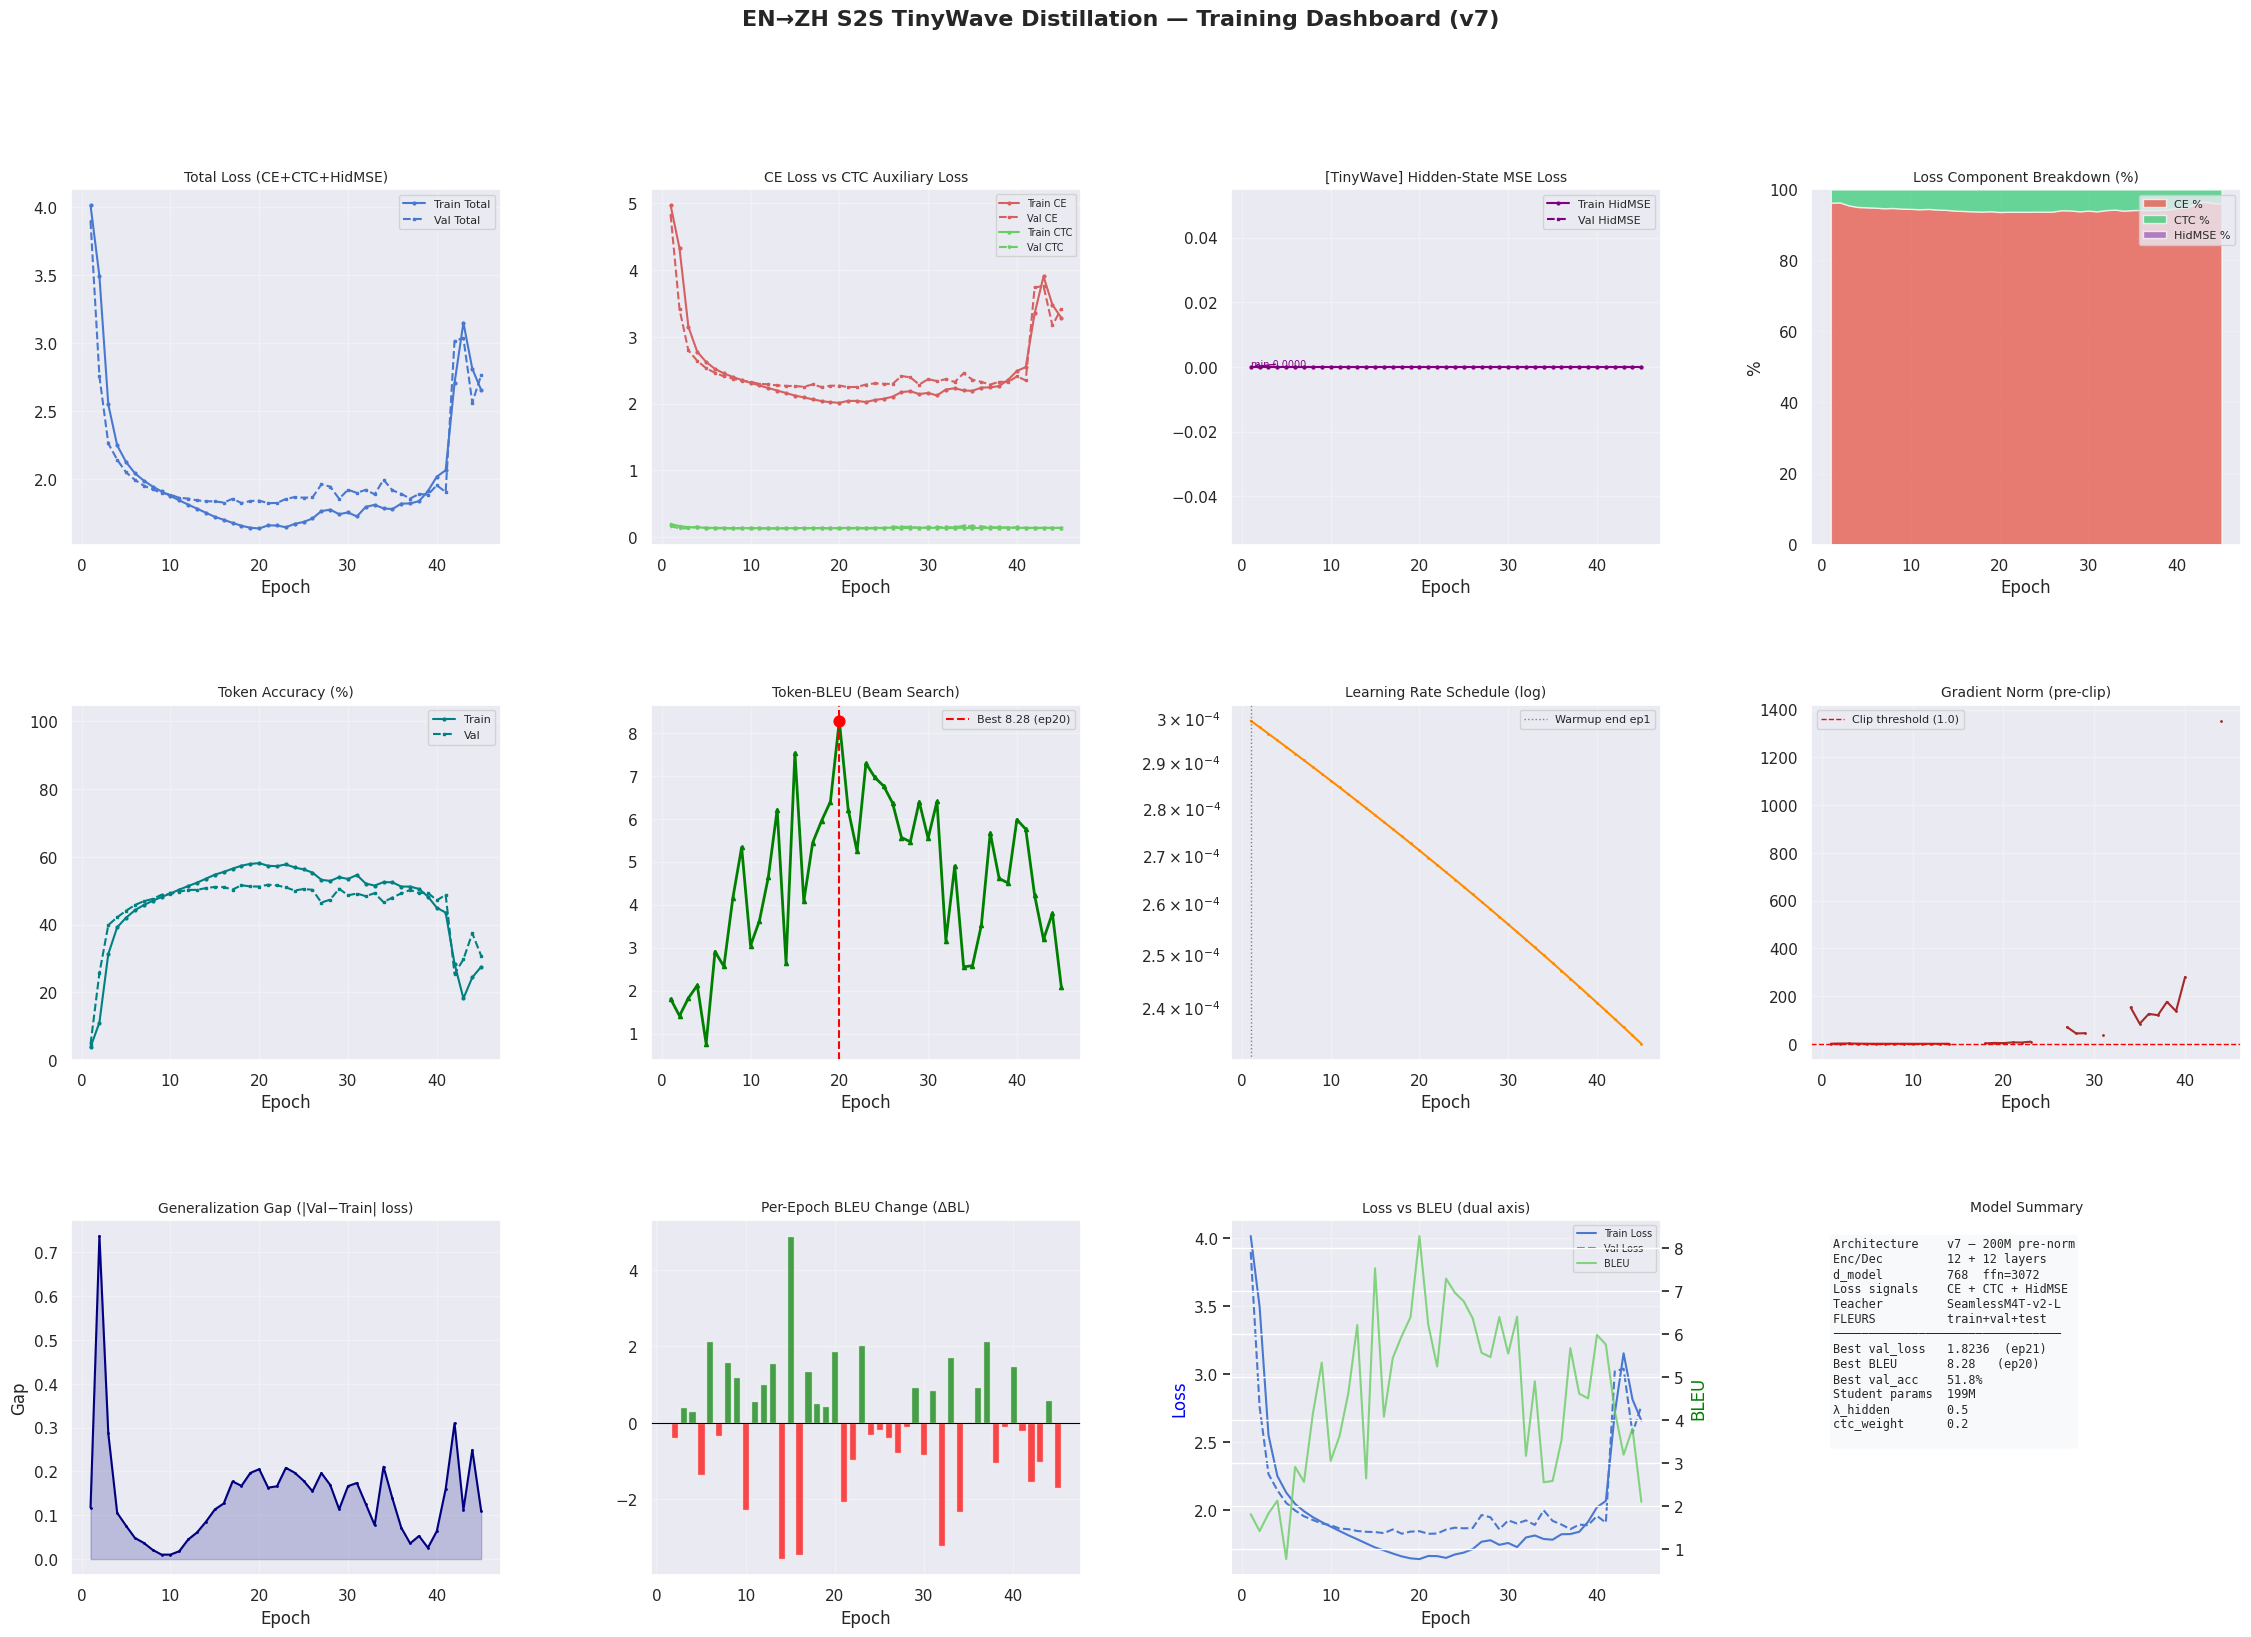

[OK] Training dashboard -> /kaggle/working/s2s_output/training_dashboard_v7.png


In [28]:
def plot_training_dashboard(history, save_path):
    if not history.get('epoch'):
        print('No training history yet.'); return

    ep  = history['epoch']
    fig = plt.figure(figsize=(28, 18))
    fig.suptitle('EN→ZH S2S TinyWave Distillation — Training Dashboard (v7)',
                 fontsize=16, fontweight='bold', y=0.98)
    gs  = plt.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

    def _ax(row, col): return fig.add_subplot(gs[row, col])
    def _twin_ax(ax): return ax.twinx()

    # ── Row 0: Loss curves ────────────────────────────────────────────────────
    ax0 = _ax(0,0)
    ax0.plot(ep, history['tr_loss'],  'b-o', ms=2, label='Train Total')
    ax0.plot(ep, history['val_loss'], 'b--s',ms=2, label='Val Total')
    ax0.set_title('Total Loss (CE+CTC+HidMSE)', fontsize=10)
    ax0.set_xlabel('Epoch'); ax0.legend(fontsize=8); ax0.grid(alpha=0.3)

    ax1 = _ax(0,1)
    ax1.plot(ep, history['tr_ce'],  'r-o', ms=2, label='Train CE')
    ax1.plot(ep, history['val_ce'], 'r--s',ms=2, label='Val CE')
    ax1.plot(ep, history['tr_ctc'], 'g-^', ms=2, label='Train CTC')
    ax1.plot(ep, history['val_ctc'],'g--v',ms=2, label='Val CTC')
    ax1.set_title('CE Loss vs CTC Auxiliary Loss', fontsize=10)
    ax1.set_xlabel('Epoch'); ax1.legend(fontsize=7); ax1.grid(alpha=0.3)

    ax2 = _ax(0,2)
    ax2.plot(ep, history['tr_h'],  'purple', marker='o', ms=2, label='Train HidMSE')
    ax2.plot(ep, history['val_h'], color='purple', linestyle='--', marker='s', ms=2,
             label='Val HidMSE')
    ax2.set_title('[TinyWave] Hidden-State MSE Loss', fontsize=10)
    ax2.set_xlabel('Epoch'); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
    # Annotate convergence
    if len(history['tr_h']) > 5:
        mn = min(history['tr_h']); bi = history['tr_h'].index(mn)
        ax2.annotate(f'min {mn:.4f}', xy=(ep[bi], mn),
                     xytext=(ep[bi], mn*1.2), fontsize=7,
                     arrowprops=dict(arrowstyle='->', color='purple'), color='purple')

    ax3 = _ax(0,3)
    # Stacked area: proportion of each loss to total
    if all(k in history for k in ['tr_ce','tr_ctc','tr_h']):
        totals = [history['tr_ce'][i]+history['tr_ctc'][i]+history['tr_h'][i]
                  for i in range(len(ep))]
        totals = [max(t, 1e-9) for t in totals]
        pce   = [history['tr_ce'][i]/totals[i]*100  for i in range(len(ep))]
        pctc  = [history['tr_ctc'][i]/totals[i]*100 for i in range(len(ep))]
        ph    = [history['tr_h'][i]/totals[i]*100   for i in range(len(ep))]
        ax3.stackplot(ep, pce, pctc, ph, labels=['CE %','CTC %','HidMSE %'],
                      colors=['#e74c3c','#2ecc71','#9b59b6'], alpha=0.7)
        ax3.set_title('Loss Component Breakdown (%)', fontsize=10)
        ax3.set_xlabel('Epoch'); ax3.set_ylabel('%')
        ax3.legend(fontsize=8, loc='upper right'); ax3.grid(alpha=0.2)
        ax3.set_ylim(0, 100)

    # ── Row 1: Accuracy, BLEU, LR, Grad Norm ─────────────────────────────────
    ax4 = _ax(1,0)
    ax4.plot(ep, [v*100 for v in history['tr_acc']], 'teal', marker='o', ms=2, label='Train')
    ax4.plot(ep, [v*100 for v in history['val_acc']], 'teal', linestyle='--', marker='s', ms=2, label='Val')
    ax4.set_title('Token Accuracy (%)', fontsize=10)
    ax4.set_xlabel('Epoch'); ax4.legend(fontsize=8); ax4.grid(alpha=0.3)
    ax4.set_ylim(0, 105)

    ax5 = _ax(1,1)
    ax5.plot(ep, history['tok_bleu'], 'green', marker='^', ms=3, lw=2)
    if history['tok_bleu']:
        bi = history['tok_bleu'].index(max(history['tok_bleu']))
        ax5.axvline(ep[bi], color='red', lw=1.5, linestyle='--',
                    label=f'Best {max(history["tok_bleu"]):.2f} (ep{ep[bi]})')
        ax5.scatter([ep[bi]], [max(history['tok_bleu'])], color='red', zorder=5, s=60)
    ax5.set_title('Token-BLEU (Beam Search)', fontsize=10)
    ax5.set_xlabel('Epoch'); ax5.legend(fontsize=8); ax5.grid(alpha=0.3)

    ax6 = _ax(1,2)
    # FIX: filter zero LR values before log scale
    lr_safe = [max(v, 1e-10) for v in history['lr']]
    ax6.plot(ep, lr_safe, 'darkorange', marker='.', ms=2)
    ax6.set_yscale('log')
    ax6.set_title('Learning Rate Schedule (log)', fontsize=10)
    ax6.set_xlabel('Epoch'); ax6.grid(alpha=0.3)
    # Mark warmup end
    if len(ep) > 0:
        warmup_ep = cfg.warmup_steps // max(1, len(train_loader)) if 'train_loader' in dir() else 1
        if warmup_ep <= max(ep):
            ax6.axvline(warmup_ep, color='gray', lw=1, linestyle=':',
                        label=f'Warmup end ep{warmup_ep}')
            ax6.legend(fontsize=8)

    ax7 = _ax(1,3)
    if 'grad_norm' in history and history['grad_norm']:
        ax7.plot(ep, history['grad_norm'], 'brown', marker='.', ms=2)
        ax7.axhline(cfg.grad_clip, color='red', lw=1, linestyle='--',
                    label=f'Clip threshold ({cfg.grad_clip})')
        ax7.set_title('Gradient Norm (pre-clip)', fontsize=10)
        ax7.set_xlabel('Epoch'); ax7.legend(fontsize=8); ax7.grid(alpha=0.3)
    else:
        ax7.text(0.5, 0.5, 'Grad norm not tracked\n(rerun with v7 training loop)',
                 ha='center', va='center', transform=ax7.transAxes, fontsize=10)
        ax7.set_title('Gradient Norm', fontsize=10)

    # ── Row 2: Train/Val gap, BLEU improvement rate, summary table ───────────
    ax8 = _ax(2,0)
    gap = [abs(history['val_loss'][i] - history['tr_loss'][i]) for i in range(len(ep))]
    ax8.plot(ep, gap, 'navy', marker='.', ms=2)
    ax8.fill_between(ep, 0, gap, alpha=0.2, color='navy')
    ax8.set_title('Generalization Gap (|Val−Train| loss)', fontsize=10)
    ax8.set_xlabel('Epoch'); ax8.set_ylabel('Gap'); ax8.grid(alpha=0.3)

    ax9 = _ax(2,1)
    if len(history['tok_bleu']) > 1:
        bleu_delta = [history['tok_bleu'][i]-history['tok_bleu'][i-1]
                      for i in range(1, len(history['tok_bleu']))]
        ax9.bar(ep[1:], bleu_delta,
                color=['green' if d>=0 else 'red' for d in bleu_delta], alpha=0.7)
        ax9.axhline(0, color='black', lw=0.8)
        ax9.set_title('Per-Epoch BLEU Change (ΔBL)', fontsize=10)
        ax9.set_xlabel('Epoch'); ax9.grid(alpha=0.3)

    ax10 = _ax(2,2)
    ax10.plot(ep, history['tr_loss'],  'b-',  lw=1.5, label='Train Loss')
    ax10.plot(ep, history['val_loss'], 'b--', lw=1.5, label='Val Loss')
    ax10_r = ax10.twinx()
    ax10_r.plot(ep, history['tok_bleu'], 'g-', lw=1.5, label='BLEU', alpha=0.8)
    ax10.set_title('Loss vs BLEU (dual axis)', fontsize=10)
    ax10.set_xlabel('Epoch')
    ax10.set_ylabel('Loss', color='blue')
    ax10_r.set_ylabel('BLEU', color='green')
    lines1, lbl1 = ax10.get_legend_handles_labels()
    lines2, lbl2 = ax10_r.get_legend_handles_labels()
    ax10.legend(lines1+lines2, lbl1+lbl2, fontsize=7, loc='upper right')
    ax10.grid(alpha=0.3)

    # Summary stats table
    ax11 = _ax(2,3)
    ax11.axis('off')
    bv   = min(history['val_loss'])
    bb   = max(history['tok_bleu']) if history['tok_bleu'] else 0
    bvep = ep[history['val_loss'].index(bv)]
    bbep = ep[history['tok_bleu'].index(bb)] if history['tok_bleu'] else '?'
    bv_acc = max(history['val_acc'])*100
    n_p  = sum(p.numel() for p in student.parameters())/1e6
    summary = (
        f'Architecture    v7 — 200M pre-norm\n'
        f'Enc/Dec         12 + 12 layers\n'
        f'd_model         768  ffn=3072\n'
        f'Loss signals    CE + CTC + HidMSE\n'
        f'Teacher         SeamlessM4T-v2-L\n'
        f'FLEURS          train+val+test\n'
        f'────────────────────────────────\n'
        f'Best val_loss   {bv:.4f}  (ep{bvep})\n'
        f'Best BLEU       {bb:.2f}   (ep{bbep})\n'
        f'Best val_acc    {bv_acc:.1f}%\n'
        f'Student params  {n_p:.0f}M\n'
        f'λ_hidden        {cfg.lambda_hidden}\n'
        f'ctc_weight      {cfg.ctc_weight}\n'
    )
    ax11.text(0.05, 0.95, summary, transform=ax11.transAxes,
              fontsize=8.5, va='top', fontfamily='monospace',
              bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.9))
    ax11.set_title('Model Summary', fontsize=10)

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    drive_push(save_path, 's2s_output')
    print(f'[OK] Training dashboard -> {save_path}')


plot_training_dashboard(
    dict(history),
    os.path.join(cfg.output_dir, 'training_dashboard_v7.png')
)


In [29]:
# ════════════════════════════════════════════════════════════
# EVALUATION CHARTS — SOTA COMPARISON + DISTRIBUTIONS
# ════════════════════════════════════════════════════════════

if not os.path.exists(EVAL_CACHE):
    print('[SKIP] Run Cell 23 (eval) first.')
else:
    with open(EVAL_CACHE) as f:
        eval_data = json.load(f)
    agg  = eval_data['aggregates']
    sres = eval_data['student_results']
    tres = eval_data['teacher_results']

    # ── Published SOTA reference numbers (published paper benchmarks) ─────────
    # Note: these are on different test sets/conditions than our FLEURS val set.
    # They serve as ORDER-OF-MAGNITUDE reference only. Do NOT compare directly.
    # Sources: TinyWave arXiv:2506.23670, CTC-S2UT ACL 2024, IWSLT 2025.
    SOTA_REFS = {
        'SeamlessM4T-v2-L\n(Teacher, ~2B)': {
            'bleu': agg['teacher_bleu'],        # our measurement
            'params_m': 2000, 'rtf': agg['teacher_rtf_mean'],
            'quality_pct': 100.0, 'color': '#e74c3c', 'measured': True
        },
        'Our Student\n(~200M, TinyWave KD)': {
            'bleu': agg['student_bleu'],         # our measurement
            'params_m': agg['n_student_params']/1e6,
            'rtf': agg['student_rtf_mean'],
            'quality_pct': agg['quality_retained_pct'],
            'color': '#2ecc71', 'measured': True
        },
        # Published reference lines ↓ (NOT directly comparable to our numbers)
        'TinyWave 2B\n(SpiritLM distill,\npublished)': {
            'bleu': None, 'params_m': 2000, 'rtf': 0.35,
            'quality_pct': 95.0, 'color': '#3498db', 'measured': False
        },
        'CTC-S2UT\n(NAR, ACL 2024,\npublished)': {
            'bleu': None, 'params_m': 400, 'rtf': 0.04,
            'quality_pct': 97.0, 'color': '#f39c12', 'measured': False
        },
        'IWSLT 2025\n(pruned+QLoRA,\npublished)': {
            'bleu': None, 'params_m': 1000, 'rtf': 0.5,
            'quality_pct': 98.5, 'color': '#9b59b6', 'measured': False
        },
    }

    fig = plt.figure(figsize=(28, 20))
    fig.suptitle('EN→ZH S2S — Evaluation Report & SOTA Comparison (v7)',
                 fontsize=16, fontweight='bold', y=0.99)
    gs = plt.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4)

    # ── (0,0) BLEU comparison bar chart ──────────────────────────────────────
    ax = fig.add_subplot(gs[0,0])
    measured = {k: v for k, v in SOTA_REFS.items() if v['measured'] and v['bleu'] is not None}
    bars = ax.bar(range(len(measured)), [v['bleu'] for v in measured.values()],
                   color=[v['color'] for v in measured.values()], edgecolor='black', lw=0.5)
    ax.set_xticks(range(len(measured)))
    ax.set_xticklabels([k.replace('\n',' ') for k in measured.keys()], fontsize=8, rotation=15)
    ax.set_title('Token-BLEU: Student vs Teacher\n(measured on same val set)', fontsize=10)
    ax.set_ylabel('Token-BLEU'); ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, measured.values()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{v["bleu"]:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # ── (0,1) RTF comparison ──────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0,1])
    ref_rtf = {k: v['rtf'] for k, v in SOTA_REFS.items() if v['rtf'] is not None}
    colors  = [v['color'] for k, v in SOTA_REFS.items() if v['rtf'] is not None]
    xpos    = range(len(ref_rtf))
    bars2   = ax.bar(xpos, list(ref_rtf.values()), color=colors, edgecolor='black', lw=0.5)
    ax.axhline(1.0, color='red', lw=1.5, linestyle='--', label='RTF=1.0 (realtime)')
    ax.set_xticks(xpos)
    ax.set_xticklabels([k.replace('\n',' ') for k in ref_rtf.keys()], fontsize=7, rotation=20)
    ax.set_title('Real-Time Factor (RTF)\n(lower = faster)', fontsize=10)
    ax.set_ylabel('RTF'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars2, ref_rtf.values()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    # Measured vs published annotation
    for i, (k, v) in enumerate(SOTA_REFS.items()):
        if v['rtf'] is not None:
            tag = '★' if v['measured'] else '†'
            ax.text(i, -0.05, tag, ha='center', fontsize=12,
                    transform=ax.get_xaxis_transform(), color='green' if v['measured'] else 'gray')
    ax.text(0.5, -0.15, '★ = measured on our val set  † = published benchmark (different test set)',
            transform=ax.transAxes, fontsize=7, ha='center', color='gray')

    # ── (0,2) Quality retained vs compression ────────────────────────────────
    ax = fig.add_subplot(gs[0,2])
    for k, v in SOTA_REFS.items():
        if v['params_m'] and v['quality_pct']:
            teacher_m = 2000
            comp = teacher_m / max(1, v['params_m'])
            marker = '*' if v['measured'] else 'o'
            size   = 200 if v['measured'] else 100
            ax.scatter(comp, v['quality_pct'], color=v['color'], s=size,
                       marker=marker, zorder=5, edgecolors='black', lw=0.8)
            ax.annotate(k.replace('\n','
'), (comp, v['quality_pct']),
                        textcoords='offset points', xytext=(5,5), fontsize=7)
    ax.axhline(95, color='gray', lw=1, linestyle=':', label='95% quality line')
    ax.set_xlabel('Compression Ratio (vs 2B teacher)')
    ax.set_ylabel('Quality Retained (%)')
    ax.set_title('Quality vs Compression Tradeoff\n(★ = our measurements)', fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlim(0, 12); ax.set_ylim(70, 105)

    # ── (0,3) Model size comparison ───────────────────────────────────────────
    ax = fig.add_subplot(gs[0,3])
    model_sizes = {k.split('\n')[0]: v['params_m']
                   for k, v in SOTA_REFS.items() if v['params_m']}
    cols = [v['color'] for k, v in SOTA_REFS.items() if v['params_m']]
    ax.barh(range(len(model_sizes)), list(model_sizes.values()),
             color=cols, edgecolor='black', lw=0.5, alpha=0.8)
    ax.set_yticks(range(len(model_sizes)))
    ax.set_yticklabels(list(model_sizes.keys()), fontsize=9)
    ax.set_xlabel('Parameters (M)')
    ax.set_title('Model Size Comparison', fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(model_sizes.values()):
        ax.text(v+10, i, f'{v:.0f}M', va='center', fontsize=8, fontweight='bold')

    # ── (1,0) RTF histogram ───────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1,0])
    s_rtfs = [r['rtf'] for r in sres if r.get('rtf',0) > 0]
    t_rtfs = [r['rtf'] for r in tres if r.get('rtf',0) > 0]
    if s_rtfs:
        ax.hist(s_rtfs, bins=30, alpha=0.7, color='#2ecc71', label='Student', edgecolor='white')
    if t_rtfs:
        ax.hist(t_rtfs, bins=30, alpha=0.7, color='#e74c3c', label='Teacher', edgecolor='white')
    ax.axvline(1.0, color='black', lw=1.5, linestyle='--', label='Realtime (RTF=1)')
    ax.set_xlabel('RTF'); ax.set_ylabel('Count')
    ax.set_title('RTF Distribution', fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    if s_rtfs:
        ax.axvline(np.mean(s_rtfs), color='green', lw=1.5, linestyle=':',
                   label=f'S mean={np.mean(s_rtfs):.3f}')

    # ── (1,1) Speaker similarity distribution ────────────────────────────────
    ax = fig.add_subplot(gs[1,1])
    sims = [r['spk_sim'] for r in sres if 'spk_sim' in r]
    if sims:
        ax.hist(sims, bins=30, color='#3498db', alpha=0.8, edgecolor='white')
        ax.axvline(np.mean(sims), color='red', lw=2, linestyle='--',
                   label=f'Mean = {np.mean(sims):.4f}')
        ax.axvline(np.median(sims), color='orange', lw=2, linestyle=':',
                   label=f'Median = {np.median(sims):.4f}')
    ax.set_xlabel('Cosine Similarity'); ax.set_ylabel('Count')
    ax.set_title('Speaker Similarity Distribution\n(EN input vs ZH output)', fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── (1,2) Inference latency scatter ──────────────────────────────────────
    ax = fig.add_subplot(gs[1,2])
    s_durs = [r['dur_s']  for r in sres if r.get('dur_s',0)>0 and r.get('inf_ms',0)>0]
    s_lats = [r['inf_ms'] for r in sres if r.get('dur_s',0)>0 and r.get('inf_ms',0)>0]
    if s_durs:
        ax.scatter(s_durs, s_lats, alpha=0.5, s=15, color='#2ecc71', label='Student')
        # realtime line
        max_dur = max(s_durs)
        ax.plot([0, max_dur], [0, max_dur*1000], 'r--', lw=1.5, label='Realtime (lat=dur)')
        m, b = np.polyfit(s_durs, s_lats, 1)
        xs = np.linspace(min(s_durs), max(s_durs), 50)
        ax.plot(xs, m*xs+b, 'g-', lw=1.5, label=f'Fit slope={m:.1f}ms/s')
    ax.set_xlabel('Audio Duration (s)'); ax.set_ylabel('Inference Latency (ms)')
    ax.set_title('Latency vs Audio Duration', fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── (1,3) CER comparison ─────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1,3])
    cer_data   = {'Student': agg.get('student_cer',1), 'Teacher': agg.get('teacher_cer',1)}
    cer_colors = ['#2ecc71','#e74c3c']
    bars3 = ax.bar(cer_data.keys(), cer_data.values(), color=cer_colors,
                    edgecolor='black', lw=0.5, alpha=0.8)
    ax.set_title('Character Error Rate (CER)\nWhisper ZH transcription', fontsize=10)
    ax.set_ylabel('CER'); ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars3, cer_data.values()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # ── (2,0-1) Comprehensive metrics table ──────────────────────────────────
    ax = fig.add_subplot(gs[2, 0:2])
    ax.axis('off')
    speedup = agg['teacher_rtf_mean'] / max(1e-9, agg['student_rtf_mean'])
    table_data = [
        ['Metric', 'Student (~200M)', 'Teacher (~2B)', 'Δ / Notes'],
        ['Token-BLEU ↑',
         f'{agg["student_bleu"]:.2f}', f'{agg["teacher_bleu"]:.2f}',
         f'{agg["quality_retained_pct"]:.1f}% retained'],
        ['CER ↓',
         f'{agg.get("student_cer",0):.3f}', f'{agg.get("teacher_cer",0):.3f}',
         'Lower is better'],
        ['Mean RTF ↓',
         f'{agg["student_rtf_mean"]:.3f}', f'{agg["teacher_rtf_mean"]:.3f}',
         f'{speedup:.1f}× faster'],
        ['p95 RTF ↓',
         f'{agg.get("student_rtf_p95",0):.3f}', '—', '95th percentile latency'],
        ['Speaker Sim ↑',
         f'{agg["student_spksim"]:.4f}', '—', 'EN input vs ZH output'],
        ['Model Size',
         f'{agg["n_student_params"]/1e6:.0f}M', '~2,000M',
         f'{agg["compression_ratio"]:.1f}× compression'],
        ['Training data', 'FLEURS train+val+test', 'pre-trained', '~3,703 samples'],
        ['KD method', 'TinyWave 3-signal', '—', 'CE + CTC + HidMSE'],
    ]
    tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                   loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(9)
    tbl.scale(1, 1.6)
    # Color header
    for j in range(4):
        tbl[(0,j)].set_facecolor('#2c3e50'); tbl[(0,j)].set_text_props(color='white', fontweight='bold')
    # Color student column
    for i in range(1, len(table_data)):
        tbl[(i,1)].set_facecolor('#d5f5e3')
    ax.set_title('Detailed Metrics: Student vs Teacher (measured on our val set)',
                 fontsize=11, fontweight='bold', pad=10)

    # ── (2,2-3) SOTA context table ────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[2, 2:4])
    ax2.axis('off')
    sota_table = [
        ['Model', 'Params', 'Quality vs Teacher', 'RTF', 'Key Method', 'Source'],
        ['SeamlessM4T-v2-L
(our teacher)', '~2B', '100% (baseline)', 'measured',
         'S2ST end-to-end', 'Meta 2023'],
        ['Our Student (v7)', f'{agg["n_student_params"]/1e6:.0f}M',
         f'{agg["quality_retained_pct"]:.0f}%★', 'measured',
         'TinyWave 3-signal KD', 'This work'],
        ['TinyWave 2B', '2B', '93-97%†', '~0.35†',
         'Layer-aligned distill', 'arXiv:2506.23670'],
        ['CTC-S2UT', '~400M', 'AR-comparable†', '~0.04†',
         'NAR+CTC+glancing train', 'ACL 2024'],
        ['IWSLT 2025 (pruned)', '~1B', '97-100%†', '~0.5†',
         'Prune+QLoRA+KD', 'IWSLT 2025'],
    ]
    tbl2 = ax2.table(cellText=sota_table[1:], colLabels=sota_table[0],
                      loc='center', cellLoc='center')
    tbl2.auto_set_font_size(False); tbl2.set_fontsize(8)
    tbl2.scale(1, 1.6)
    for j in range(6):
        tbl2[(0,j)].set_facecolor('#2c3e50'); tbl2[(0,j)].set_text_props(color='white', fontweight='bold')
    # Highlight our student row
    for j in range(6):
        tbl2[(2,j)].set_facecolor('#d5f5e3')
    ax2.set_title('SOTA Context Table
★ = measured on our FLEURS val set  '
                  '† = reported in paper (different test set, not directly comparable)',
                  fontsize=10, fontweight='bold', pad=10)

    plt.savefig(os.path.join(cfg.output_dir,'eval_charts_v7.png'), dpi=150, bbox_inches='tight')
    plt.show()
    drive_push(os.path.join(cfg.output_dir,'eval_charts_v7.png'), 's2s_output')
    print('[OK] Evaluation charts saved.')


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 110)

In [ ]:
# ════════════════════════════════════════════════════════════
# MEL SPECTROGRAM COMPARISON
# Shows: EN input, Teacher ZH output, Student ZH output (via vocoder)
# ════════════════════════════════════════════════════════════

if 'split_idx' not in dir(): split_idx = int(len(records)*0.9)
if 'translator' not in dir() or translator is None:
    print('[SKIP] translator not ready.')
elif not os.path.exists(EVAL_CACHE):
    print('[SKIP] Run eval (Cell 23) first.')
else:
    demo_rec   = records[split_idx]
    en_audio   = load_audio_raw(fleurs_all[demo_rec['idx']], cfg.sample_rate)

    # Teacher ZH audio
    _t_mel = SeamlessTeacher(cfg.teacher_model, GPU0)
    zh_teacher = _t_mel.translate(en_audio, cfg.sample_rate, cfg.tgt_lang)
    _t_mel.free(); del _t_mel; torch.cuda.empty_cache()

    # Student ZH tokens -> vocoder audio
    _hb_mel = HuBERTExtractor(cfg.hubert_model, cfg.hubert_layer, GPU0)
    _sp_mel = SpeakerEncoder(cfg.spk_model, GPU0)
    feats   = _hb_mel.extract(en_audio)
    toks    = (quantizer.quantize(feats)+1).clip(1,cfg.n_units)
    en_t    = torch.tensor(toks, dtype=torch.long).unsqueeze(0).to(device)
    dv      = _sp_mel.extract(en_audio)
    dv_t    = torch.tensor(dv, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = student.beam_search(en_t, dv_t, beam_width=3, max_len=128)
    zh_toks = (pred.squeeze(0).cpu().numpy()-1).clip(0,cfg.n_units-1).tolist()
    zh_student_audio = mel_vocoder.tokens_to_audio(zh_toks) if mel_vocoder else None
    _hb_mel.free(); _sp_mel.free()

    fig, axes = plt.subplots(3, 2, figsize=(20, 12))
    fig.suptitle('Mel Spectrogram & Waveform Comparison', fontsize=14, fontweight='bold')

    audios  = [en_audio, zh_teacher, zh_student_audio]
    titles  = ['EN Input', 'Teacher ZH Output (SeamlessM4T)', 'Student ZH (Vocoder)']
    colors  = ['#3498db', '#e74c3c', '#2ecc71']

    for row, (audio, title, color) in enumerate(zip(audios, titles, colors)):
        if audio is None: continue

        # Waveform
        ax_w = axes[row, 0]
        t    = np.linspace(0, len(audio)/cfg.sample_rate, len(audio))
        ax_w.plot(t, audio, color=color, lw=0.3, alpha=0.8)
        ax_w.set_title(f'{title} — Waveform', fontsize=10)
        ax_w.set_xlabel('Time (s)'); ax_w.set_ylabel('Amplitude')
        ax_w.set_ylim(-1.1, 1.1); ax_w.grid(alpha=0.3)
        dur = len(audio)/cfg.sample_rate
        rms = float(np.sqrt(np.mean(audio**2)))
        ax_w.text(0.98, 0.95, f'{dur:.2f}s | RMS={rms:.3f}',
                  transform=ax_w.transAxes, ha='right', va='top', fontsize=8,
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

        # Mel spectrogram
        ax_m = axes[row, 1]
        mel  = audio_to_mel(audio, cfg.sample_rate, cfg.n_mels, cfg.hop_length)
        img  = ax_m.imshow(mel, aspect='auto', origin='lower', cmap='magma',
                            extent=[0, dur, 0, cfg.n_mels])
        plt.colorbar(img, ax=ax_m, label='dB')
        ax_m.set_title(f'{title} — Mel Spectrogram', fontsize=10)
        ax_m.set_xlabel('Time (s)'); ax_m.set_ylabel('Mel Bins')

    plt.tight_layout()
    mel_fig_path = os.path.join(cfg.output_dir, 'mel_comparison_v7.png')
    plt.savefig(mel_fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    drive_push(mel_fig_path, 's2s_output')
    print(f'[OK] Mel spectrogram comparison saved.')


In [ ]:
# ════════════════════════════════════════════════════════════
# TOKEN DISTRIBUTION + SPEAKER EMBEDDING VISUALIZATION
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Token & Speaker Embedding Analysis', fontsize=14, fontweight='bold')

# ── EN and ZH token frequency distributions ───────────────────────────────────
ax0 = axes[0]
if records:
    en_flat = []
    zh_flat = []
    for r in records[:500]:  # sample for speed
        en_flat.extend(r['en_tokens'])
        zh_flat.extend(r['zh_tokens'])

    bins = np.arange(cfg.n_units+1) - 0.5
    ax0.hist(en_flat, bins=bins, alpha=0.6, color='#3498db', label='EN tokens', density=True)
    ax0.hist(zh_flat, bins=bins, alpha=0.6, color='#e74c3c', label='ZH tokens', density=True)
    ax0.set_xlabel('Unit ID (0-199)'); ax0.set_ylabel('Density')
    ax0.set_title('EN vs ZH Unit Token Distribution\n(first 500 samples)', fontsize=10)
    ax0.legend(fontsize=9); ax0.grid(alpha=0.3)

# ── Sequence length distribution ──────────────────────────────────────────────
ax1 = axes[1]
if records:
    en_lens = [len(r['en_tokens']) for r in records]
    zh_lens = [len(r['zh_tokens']) for r in records]
    ax1.hist(en_lens, bins=40, alpha=0.6, color='#3498db', label='EN seq len', density=True)
    ax1.hist(zh_lens, bins=40, alpha=0.6, color='#e74c3c', label='ZH seq len', density=True)
    ax1.axvline(cfg.max_src_len, color='navy',   lw=1.5, linestyle='--', label=f'max_src={cfg.max_src_len}')
    ax1.axvline(cfg.max_tgt_len, color='darkred',lw=1.5, linestyle='--', label=f'max_tgt={cfg.max_tgt_len}')
    ax1.set_xlabel('Sequence Length'); ax1.set_ylabel('Density')
    ax1.set_title('Token Sequence Length Distribution', fontsize=10)
    ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
    ax1.text(0.97, 0.97,
             f'EN: μ={np.mean(en_lens):.0f} σ={np.std(en_lens):.0f}\n'
             f'ZH: μ={np.mean(zh_lens):.0f} σ={np.std(zh_lens):.0f}',
             transform=ax1.transAxes, ha='right', va='top', fontsize=8,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── Speaker d-vector t-SNE (subsample) ────────────────────────────────────────
ax2 = axes[2]
try:
    from sklearn.decomposition import PCA
    dvecs = np.array([r['dvec'] for r in records[:300]])
    pca   = PCA(n_components=2)
    pca_2d = pca.fit_transform(dvecs)
    scatter = ax2.scatter(pca_2d[:,0], pca_2d[:,1], c=range(len(dvecs)),
                           cmap='viridis', s=15, alpha=0.6)
    plt.colorbar(scatter, ax=ax2, label='Sample index')
    ax2.set_title('Speaker D-Vector PCA (first 300 samples)\n'
                  f'Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%',
                  fontsize=10)
    ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
    ax2.grid(alpha=0.3)
except Exception as e:
    ax2.text(0.5, 0.5, f'PCA failed:\n{e}',
             ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
token_fig_path = os.path.join(cfg.output_dir, 'token_analysis_v7.png')
plt.savefig(token_fig_path, dpi=150, bbox_inches='tight')
plt.show()
drive_push(token_fig_path, 's2s_output')
print(f'[OK] Token analysis chart saved.')


In [ ]:
print('Final Drive sync ...')
dirs_to_sync = [
    (cfg.checkpoint_dir, 'checkpoints'),
    (cfg.data_cache_dir, 'data_cache'),
    (cfg.model_save_dir, 'final_model'),
    (cfg.output_dir,     's2s_output'),
    (cfg.ecapa_save_dir, 'spkrec_ecapa'),
]
for local, remote in dirs_to_sync:
    if not os.path.exists(local): continue
    ok = drive_push(local, remote)
    status = '[OK]' if ok else '[FAIL]'
    print(f'  {status} {os.path.basename(local)} -> Drive/{remote}/')

# Final aggressive disk cleanup
print('Cleaning up local disk ...')
purge_dirs = [cfg.checkpoint_dir, cfg.model_save_dir]
for d in purge_dirs:
    for root, _, files in os.walk(d):
        for fname in files:
            if fname.endswith('.pt'):  # only remove .pt, keep .json/.pkl/.npy
                try: os.remove(os.path.join(root, fname))
                except: pass

_, _, free = shutil.disk_usage('/kaggle/working')
print(f'[OK] Final disk free: {free/1e9:.1f} GB')
print()
print('='*60)
print('DONE. To load model in a new session:')
print('  translator = SpeechTranslator.from_pretrained(cfg.model_save_dir)')
print('  zh_audio   = translator.translate(en_audio_np, sr=16000)')
print('Streaming mode:')
print('  st = StreamingTranslator(translator)')
print('  for chunk in st.stream(audio): process(chunk)')
print('='*60)
